# Class Prediction
**Background**  
- 【背景】カフェチェーンの需要予測とCRM最適化
  - あるカフェチェーン。10店舗（Store A〜J）、1万人規模のアプリ会員を持つ
  - 「ラテ」の販促キャンペーンを本部にて検討中。的確な需要予測と合理的説明をもって店舗の支持を得ながら進行したい
- 【課題】利益の最大化、店舗オペレーションの最適化、本部提案の納得感
  - 過去の失敗経験: 昨年の同様企画では予測精度が不十分で、店舗の理解も得られず、期待を下回る結果だった
  - 予算の制約: 以前にも増して本部販促費の投資対効果が注視されており、次回施策のためにも予測精度は担保したい
  - 店舗の裁量: 発注やシフト作成は店舗判断のため、納得感ある説明および行動しやすい判断材料が求められている
  
- 【問題の設定】分類予測（誰がラテを購入するかを予測する）
  - クーポン配布という施策内容に反応しやすい顧客層を特定することでROIを最大化しつつ、予測の理由を解釈しやすい判断材料を提供する
- 【解法】LGBM, Tabular DLなど
（仮案）
1. LightGBMで素早く初動回答することで、関係者合意を取り付けやすい土壌を作りやすい企画進行を支援する
1. GBDTやTabular DLなども使うことで、説明可能性や予測精度を検証
1. hoge


In [124]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# import scipy
import sklearn
import shap
import lightgbm as lgb
# import xgboost as xgb

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas",
"numpy",
"matplotlib",
"seaborn",
"scikit-learn",
"shap",
"lightgbm",
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-06-05 09:34:47
Python 3.11.15
OS macOS-26.5.1-arm64-arm-64bit
is_google_colab: False
pandas 3.0.2
numpy 2.4.3
matplotlib 3.10.9
seaborn 0.13.2
scikit-learn 1.8.0
shap 0.51.0
lightgbm 4.6.0


サンプルデータの設定  
- 配下10店舗それぞれの過去3ヶ月の、顧客別ラテ注文実績＋関連データ
- 結果変数 is_purchased: 顧客がその日にラテを購入したかどうかの二値
- 予測には役立ちそうもない特徴量を混ぜたり、一部を欠損値にしたりゴミを混ぜたりしている（現実データっぽい感じにしつつ、素早く初動回答するにあたり最低限のデータクリーニングチェックすることを意図）


以下だとおそらく、past_latte_ratioやpast_coupon_usage_rateがずっと同じ状態でデータ生成されちゃうので、これを店舗*customer_idごとに時点を経るたびに変わるようなのに差し替えたいところ

In [125]:
# # # サンプルのdataframeを生成する
# import string

# # --- 基本設定 ---
# # start_date = pd.to_datetime("2025-09-01")  # 開始日
# # n_days = 92  # 3ヶ月分くらいある設定にする
# # n_stores = 10  # 10店舗くらいある設定にする
# # n_customers = 10000  # 顧客は10000人くらい


# def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
#     np.random.seed(42)
    
#     # --- 1. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     dates = pd.date_range(start='2025-09-01', periods=n_days)
    
#     # 顧客マスタ（10,000人）
#     chars = list(string.ascii_lowercase + string.digits)
#     unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
#     customer_master = pd.DataFrame({
#         'customer_id': unique_customer_ids,
#         # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
#         'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
#         # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
#         'past_latte_ratio': np.random.beta(2, 5, n_customers),
#         # 過去のクーポン利用率（感度の代理指標）
#         'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
#     })

#     # 店舗×日付単位の外部環境マスタを作成
#     env_data = []
#     for d in dates:
#         is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
#         is_weekend = 1 if d.dayofweek >= 5 else 0
#         daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
#         for s in store_ids:
#             env_data.append({
#                 'date': d,
#                 'store_id': s,
#                 'is_raining': is_raining,
#                 'is_weekend': is_weekend,
#                 'current_temp': daily_temp_base + np.random.normal(0, 0.5),
#                 # わざと役立ちそうにない特徴量を含める
#                 'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
#                 'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
#             })
#     df_env = pd.DataFrame(env_data)

#     # --- 2. 来店イベントの生成 ---
#     # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
#     # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
#     avg_visits_per_7days = 3  # 7日で平均3回来店する設定
#     lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
#     customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

#     all_visits = []
#     for _, row in customer_master.iterrows():
#         if row['total_visits'] == 0: continue
        
#         # 来店回数分だけ行を生成
#         for _ in range(row['total_visits']):
#             all_visits.append({
#                 'customer_id': row['customer_id'],
#                 'date': np.random.choice(dates),  # ランダムな日に来店
#                 'store_id': np.random.choice(store_ids)  # ランダムな店に来店
#             })
    
#     df_main = pd.DataFrame(all_visits)
#     # マスタとマージ
#     df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
#     df = df.merge(df_env, on=['date', 'store_id'])

#     # --- 3. 購買ロジックの適用 ---
#     # 店舗ごとの地力（固定効果）
#     store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
#     # 処置（クーポン配布）は来店ごとに50%の確率
#     df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
#     # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
#     df['app_total_pv'] = np.random.poisson(5, len(df))

#     # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
#     logit = (
#         -3.0
#         + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
#         + (df['is_treatment'] * df['past_coupon_usage_rate'] * 6.0)  # クーポンも効く
#         + df['store_id'].map(store_bias)  # 店舗バイアスある
#         + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
#         - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
#     )
    
#     prob = 1 / (1 + np.exp(-logit))
#     df['is_purchased'] = np.random.binomial(1, prob)
    
#     # わざと欠損値を含める
#     df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
#     # わざとobject型にする
#     df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
#     # わざと?を混入させる
#     dirty_idx = df.sample(frac=0.005).index
#     df.loc[dirty_idx, 'past_latte_ratio'] = '?'
#     # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
#     df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

#     # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
#     return df  # わざとソートせずに出力

# df1 = generate_cafe_data_v3()

In [126]:
# # サンプルのdataframeを生成する
import string

# --- 基本設定 ---
# start_date = pd.to_datetime("2025-09-01")  # 開始日
# n_days = 92  # 3ヶ月分くらいある設定にする
# n_stores = 10  # 10店舗くらいある設定にする
# n_customers = 10000  # 顧客は10000人くらい


def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
    np.random.seed(42)
    
    # --- 1. マスタ作成 ---
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    dates = pd.date_range(start='2025-09-01', periods=n_days)
    
    # 顧客マスタ（10,000人）
    chars = list(string.ascii_lowercase + string.digits)
    unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    customer_master = pd.DataFrame({
        'customer_id': unique_customer_ids,
        # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
        'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
        # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
        'past_latte_ratio': np.random.beta(2, 5, n_customers),
        # 過去のクーポン利用率（感度の代理指標）
        'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
    })

    # 店舗×日付単位の外部環境マスタを作成
    env_data = []
    for d in dates:
        is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
        is_weekend = 1 if d.dayofweek >= 5 else 0
        daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
        for s in store_ids:
            env_data.append({
                'date': d,
                'store_id': s,
                'is_raining': is_raining,
                'is_weekend': is_weekend,
                'current_temp': daily_temp_base + np.random.normal(0, 0.5),
                # わざと役立ちそうにない特徴量を含める
                'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
                'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
            })
    df_env = pd.DataFrame(env_data)

    # --- 2. 来店イベントの生成 ---
    # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
    # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
    avg_visits_per_7days = 3  # 7日で平均3回来店する設定
    lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
    customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

    all_visits = []
    for _, row in customer_master.iterrows():
        if row['total_visits'] == 0: continue
        
        # 来店回数分だけ行を生成
        for _ in range(row['total_visits']):
            all_visits.append({
                'customer_id': row['customer_id'],
                'date': np.random.choice(dates),  # ランダムな日に来店
                'store_id': np.random.choice(store_ids)  # ランダムな店に来店
            })
    
    df_main = pd.DataFrame(all_visits)
    # マスタとマージ
    df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
    df = df.merge(df_env, on=['date', 'store_id'])

    # --- 3. 購買ロジックの適用 ---
    # 店舗ごとの地力（固定効果）
    store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
    # 処置（クーポン配布）は来店ごとに50%の確率
    df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
    # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
    df['app_total_pv'] = np.random.poisson(5, len(df))

    # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
    logit = (
        -4.5
        + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
        + (df['is_treatment'] * df['past_coupon_usage_rate'] * 3.0)  # クーポンも効く
        + df['store_id'].map(store_bias)  # 店舗バイアスある
        + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
        - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
    )
    
    prob = 1 / (1 + np.exp(-logit))
    df['is_purchased'] = np.random.binomial(1, prob)
    
    # わざと欠損値を含める
    df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
    # わざとobject型にする
    df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
    # わざと?を混入させる
    dirty_idx = df.sample(frac=0.005).index
    df.loc[dirty_idx, 'past_latte_ratio'] = '?'
    # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
    df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

    # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
    return df  # わざとソートせずに出力

df1 = generate_cafe_data_v3()

In [127]:
# 土日祝日フラグを追加する
# 土日や平日祝日は、平日と傾向異なるとは限らないが、時点データであれば周期性考慮してもよさそうなため早い段階で差し込む

# 1. 祝日データの作成
import jpholiday

# df['ds'] から期間の開始日と終了日を取得
start = df1['date'].min()
end = df1['date'].max()
# または手打ち
# start = pd.to_datetime("2025-07-01")
# end = pd.to_datetime("2025-07-31")

# 年をまたぐ可能性考えて、ユニークな年を取得
years = df1['date'].dt.year.unique()

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name})

holidays_df = pd.DataFrame(holidays_list)
holidays_df

,ds,holiday
0,2025-09-15,敬老の日
1,2025-09-23,秋分の日
2,2025-10-13,スポーツの日
3,2025-11-03,文化の日
4,2025-11-23,勤労感謝の日
5,2025-11-24,勤労感謝の日 振替休日


In [128]:
# 2. 土日フラグを立てておいて（5:土曜日, 6:日曜日）
df1["is_holiday"] = df1["date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. holidays_df に含まれる日付（平日祝日）を 1 に更新する
# dt.normalize() を使うと時刻が 00:00:00 に揃うので比較が確実
holiday_dates = holidays_df['ds'].dt.normalize()
df1.loc[df1['date'].dt.normalize().isin(holiday_dates), "is_holiday"] = 1

# Speedy Check
- データセットの中身、行列数、データ型は意図通りか、混入物がないか確認
- データの不完全さを素早く直感的に把握し、データのクリーニング方法などを適切に判断する
- この段階ではデータをキレイにするところがゴール
- Null（NaN）をどう扱うかは後回し

In [129]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

# カラム名と中身が違ってそうな場合、そのデータセットは本来のものなのか、単にカラム名が違ってただけなのか、列がズレてるのかなどを疑う必要あり

  customer_id       date store_id  membership_years past_latte_ratio  \
0    2ohuswkk 2025-10-04  Store_A               0.5         0.117972   
1    2ohuswkk 2025-09-30  Store_G               0.5         0.117972   
2    2ohuswkk 2025-11-19  Store_E               0.5         0.117972   
3    2ohuswkk 2025-10-17  Store_I               0.5         0.117972   
4    2ohuswkk 2025-11-29  Store_J               0.5         0.117972   

   past_coupon_usage_rate  is_raining  is_weekend  current_temp  \
0                0.129511           0           1     19.734029   
1                0.129511           0           0           NaN   
2                0.129511           1           0     19.189416   
3                0.129511           0           0     17.736123   
4                0.129511           0           1     17.948516   

   station_congestion_index  daily_staffing_cost  is_treatment  app_total_pv  \
0                 90.909776               110125             0             8   
1   

In [130]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
print(df1.info())

# 期待してるデータ型になってない場合は、中に変なものが混入してるのかも

(394899, 15)
<class 'pandas.DataFrame'>
RangeIndex: 394899 entries, 0 to 394898
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_id               394899 non-null  str           
 1   date                      394899 non-null  datetime64[us]
 2   store_id                  394899 non-null  str           
 3   membership_years          394899 non-null  float64       
 4   past_latte_ratio          394899 non-null  object        
 5   past_coupon_usage_rate    355409 non-null  float64       
 6   is_raining                394899 non-null  int64         
 7   is_weekend                394899 non-null  int64         
 8   current_temp              383052 non-null  float64       
 9   station_congestion_index  394899 non-null  float64       
 10  daily_staffing_cost       394899 non-null  int64         
 11  is_treatment              394899 non-null  int64         
 12  

## dtypes number
- 数値型扱いになっているが、例えばカテゴリ変数や文字列として扱いたいカラムが混ざっていないか？のチェック
  - 例えば、非数値型を思わせるid/code/typeのような文字を含むカラム名だったり、ユニーク数が極端に少ないカラムなど
  - 例えば、yyyymmddが年/月/日に分かれて格納されてるなど、hh時間帯や曜日など
  - 例えば、顧客属性やなんらかのセグメントを表す名義尺度のような情報が数値で格納されているなど

1. 自作関数で洗い出してみる
1. ユニーク値を目視
1. 要約統計量を見る(ドメイン知識からして極端な外れ値が混入していないか？のチェックは後でもいい)

In [131]:
# データ型の把握（数値型のみ）
df1.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 394899 entries, 0 to 394898
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   membership_years          394899 non-null  float64
 1   past_coupon_usage_rate    355409 non-null  float64
 2   is_raining                394899 non-null  int64  
 3   is_weekend                394899 non-null  int64  
 4   current_temp              383052 non-null  float64
 5   station_congestion_index  394899 non-null  float64
 6   daily_staffing_cost       394899 non-null  int64  
 7   is_treatment              394899 non-null  int64  
 8   app_total_pv              394899 non-null  int64  
 9   is_purchased              394899 non-null  int64  
 10  is_holiday                394899 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 33.1 MB


In [132]:
def suggest_non_number_columns(df):
    """
    数値型だけど、実は非数値型かもしれないカラムを提案するにゃん。
    """
    suspicious_cols = []
    for col in df.select_dtypes(include=['number']).columns:
        # 1. カラム名にカテゴリ変数やなんらかの識別子を思わせる文字が含まれているか
        # 2. あるいは、ユニークな値の数が極端に少ない（例：データ量の1%未満など）
        unique_count = df[col].nunique()
        if any(keyword in col.lower() for keyword in ["id", "code", "type", "day", "flag"]):
            suspicious_cols.append((col, unique_count))
            
    if suspicious_cols:
        print("💡 以下の数値型カラムは、非数値型に変えたほうがいいかもしれないにゃん：")
        for col, count in suspicious_cols:
            print(f"   ∟ {col} (ユニーク値: {count}件)")
    else:
        print("✅ 数値型カラムに非数値型っぽいものは見当たらないにゃん。")

# 実行
suggest_non_number_columns(df1)

# 出力結果は指定ルールにヒットしたものをあくまで提案してるだけなので、実際に変えるかは以降内容踏まえて都度判断する

💡 以下の数値型カラムは、非数値型に変えたほうがいいかもしれないにゃん：
   ∟ is_holiday (ユニーク値: 2件)


In [133]:
# 変更するか検討のために、ユニーク値の種別を把握
print(df1['is_holiday'].unique())

# ユニーク値別に頻度（行数）を見てみる
df1.groupby('is_holiday').size()

# このカラムは（2値なので）数値型扱いでも支障なさそうなのでこのままとする

[1 0]


is_holiday
0    262161
1    132738
dtype: int64

In [134]:
# # 数値型カラムのうち、数値型の必要性がないカラムを文字列型に変換するなら、
# df1["value_id"] = df1["value_id"].astype('str') 
# df1["value_id"] = df1["value_id"].astype('string')   # pandasが古い例えばv1.5とかならstringを指定した方がいいかも

# # NaNはNaNのまま残して、数字だけを文字列（str）に変換する
# df1["value_id"] = df1["value_id"].map(lambda x: str(int(x)) if pd.notnull(x) else x)
# # ※小数点以下も含むような数値を想定して、int(x)を挟んでからstr()にしている

In [135]:
# 数値型カラムのうち、カテゴリ変数にしたいカラムを型変換するなら、

# 一度文字列にしてからcategory型にする
# df1["value_id"] = df1["value_id"].astype(str).astype("category")

# 順序に意味があるカテゴリ変数にしたい場合（満足度 high/mid/lowや曜日など）
# 並び順を指定してcategory型にする
# weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# df1["weekday"] = pd.Categorical(df1["weekday"].astype(str), categories=weekday_order, ordered=True)
# 特徴量として使う際に、モデルがこの並び順でなんらか傾向があるかも？と並び順の情報を保持したまま学習してくれる

In [136]:
# 数値型カラムのうち、明らかにyyyymmddなのでdatetime型に変換するなら、
# df1["date"] = pd.to_datetime(df1["date"].astype(str))　　# 一度文字列にしてから変換

# 数値型カラムのうち、例えばyyyymmddが年/月/日に分かれて格納されてるのを、束ねてdatetimeに型変換するなら、
# カラム名が 'year', 'month', 'day' ならこれで
# df1['date'] = pd.to_datetime(df1[['year', 'month', 'day']])
# あるいは辞書形式で指定する
# df1['date'] = pd.to_datetime({'year': df1['yyyy'], 'month': df1['mm'], 'day': df1['dd']})

## dtypes exclude number
- 非数値型扱いになっているが、数値として扱いたいカラムが混ざっていないか？のチェック
  - 例えば、連続値データだけと思ってたら、?や空文字（スペースだけ）のような文字が混入していて文字列扱いになっているなど
  - 例えば、エクセルで数値の先頭にシングルクォーテーションをつけてたり、文字列設定にしていて文字列扱いになっているなど

In [137]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 394899 entries, 0 to 394898
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   customer_id       394899 non-null  str           
 1   date              394899 non-null  datetime64[us]
 2   store_id          394899 non-null  str           
 3   past_latte_ratio  394899 non-null  object        
dtypes: datetime64[us](1), object(1), str(2)
memory usage: 12.1+ MB


## why not numeric
- 文字列カラム（str, string, object）の中身を把握
- 数値型であって欲しいのに、文字列扱いになっているカラムへの混入物を目視のうえで無くしたい意図（isnullではヒットしないため）

In [138]:
# チェックしたいカラムをリストアップ（文字列扱いカラムのうち、そうであって欲しくないカラムのみ）
# ここでは文字列扱いじゃないカラムもうっかり含めちゃった想定にしている（自作関数のフィルタチェック目的でもある）
target_numeric_cols = ['membership_years', 'past_latte_ratio', 'current_temp']

In [139]:
def scan_numeric_columns(df, target_cols):
    """
    数値型であって欲しいカラムをスキャンし、数値以外のデータが混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのものだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値型であって欲しいカラムの混入チェック ---")
    for col in check_cols:
        # 数値に変換を試みる（数値にできないエラーのぶんはNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        # もともとNaNではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        # 混入物が入っている行だけを抽出
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not non_numeric_rows.empty:
            total_count = len(df)
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            rate = (total_non_numeric / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 数値以外のデータ: {total_non_numeric:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべて数値に変換可能だにゃん！")

In [140]:
scan_numeric_columns(df1, target_numeric_cols)

--- 🔍 数値型であって欲しいカラムの混入チェック ---
⚠️ past_latte_ratio
   ∟ 総数: 394,899 件
   ∟ 数値以外のデータ: 1,974 件 (0.50 %)
   ∟ 詳細: 
      - '?': 1,974 件
-----------------------------------


In [141]:
# 混入物の処理方法案

# 不要な文字列は混入しているが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# 数値にできない文字列は強制的にNaN（欠損値）に置換する（NaNを含むので強制的にfloat64型になる）
df1['past_latte_ratio'] = pd.to_numeric(df1['past_latte_ratio'], errors='coerce')
# このカラムでは数値以外のデータが少数なことと、素早い初動回答を優先して、これをおこなう


# # この文字は0にしたい、この文字は欠損値扱いにしたいなどの明確な根拠、意思がある場合
# # replaceで明示的に特定の文字を、それぞれ置換してからastype
# df1['value1'] = df1['value1'].replace({'?': 0, 'Unknown': np.nan}).astype(float)  # ?は0に、UnknownはNaNに置換
# df1["value1"] = df1["value1"].replace(["", "?"], np.nan)  # 空白と?はNaNに置換

# "1,200円"のように数字に関連する余計な文字がくっついている場合
# 正規表現で数字以外を削ぎ落とす（数字、小数点、マイナス記号以外を全部消す）
# df1['value1'] = df1['value1'].str.replace(r'[^0-9.-]', '', regex=True).astype(float)

In [142]:
# （混入物はなく明らかに全て数値情報のみなんだが）文字列扱いになっているカラムを、数値型に変換する
# df1["value1"] = df1["value1"].astype(float)

In [143]:
# 数値型の要約統計量（平均、標準偏差、最小値、最大値など）を把握
df1.describe(include='number')

# でもこのタイミングで実行したからといって、あんまりチェックにはなってないような？

,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
count,394899.000000,392925.000000,355409.000000,394899.000000,394899.000000,383052.000000,394899.000000,394899.000000,394899.000000,394899.000000,394899.000000,394899.000000
mean,2.061748,0.284269,0.249616,0.119874,0.282361,16.973341,100.097872,100481.090545,0.499971,4.997032,0.193728,0.336132
std,1.926196,0.159338,0.193270,0.324814,0.450149,1.470321,15.357574,29043.664444,0.500001,2.234420,0.395219,0.472385
min,0.500000,0.001339,0.000010,0.000000,0.000000,13.797492,58.762487,50137.000000,0.000000,0.000000,0.000000,0.000000
25%,0.576177,0.158964,0.092209,0.000000,0.000000,15.739734,89.523317,74787.000000,0.000000,3.000000,0.000000,0.000000
50%,1.367602,0.264098,0.208713,0.000000,0.000000,16.984901,99.612794,100567.000000,0.000000,5.000000,0.000000,0.000000
75%,2.795055,0.386095,0.367793,0.000000,1.000000,18.110059,110.020725,126158.000000,1.000000,6.000000,0.000000,1.000000
max,10.000000,0.865203,0.959468,1.000000,1.000000,20.124025,153.073667,149978.000000,1.000000,18.000000,1.000000,1.000000


## why not datetime
- 時点情報のカラムがdatetime型になっていない原因を把握する
- 時点情報がdatetime型でなくとも不都合感じない場合もあるが、期間の計算やダウンサンプリングで苦労する

In [144]:
# datetime型であって欲しいのに、文字列扱いになっているカラムをリストアップ
target_datetime_cols = ['date']

In [145]:
def scan_datetime_columns(df, target_cols):
    """
    datetime型にしたいカラムをスキャンし、日付として読み取れない文字を特定するにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのものだけを抽出
    # datetime型に変換済みのカラムがtarget_date_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!")
        return

    print("--- 🔍 日付列のフォーマット不備チェック ---")
    for col in check_cols:
        # 日付型に変換を試みる（日付にできないエラーのぶんはNaNになる）
        converted = pd.to_datetime(df[col], errors='coerce')
        # もともとNaNではなく、日付変換によって新たにNaNになった値（＝混入物）を特定
        invalid_date_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not invalid_date_rows.empty:
            total_count = len(df)
            counts = invalid_date_rows.value_counts()
            total_invalid = counts.sum()
            rate = (total_invalid / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 日付にできないデータ: {total_invalid:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべての日付が正しく変換可能だにゃん!")

In [146]:
scan_datetime_columns(df1, target_datetime_cols)

✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!


In [147]:
# # 文字列扱いの日付データをdatetime型に変換する

# # 全カラムが明らかに日付情報のみであることが確実な場合に（文字列混入していると実行エラーになる）
# df1["date"] = pd.to_datetime(df1["date"])

# # 不要な文字列が混入してるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 日付にできない文字列は強制的にNaN（欠損値）に置換したうえで、削除する
# df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
# before_count = len(df1)  # 日付がNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['date']).reset_index(drop=True)  # 日付がNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # 日付がNaNの行を削除した後の行数
# print(f"日付不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# 日付データのカラムの中身がもっと変で複雑な場合は、適宜加工してキレイに変換する（ここでは省略）

## describe
- 数値型カラムの平均、標準偏差、最小値、最大値などを把握
  - ドメイン知識からして極端な外れ値が混入していないか？のチェックをしたい意図
- 非数値型カラムのユニークカウント、最頻値、範囲などを把握

In [148]:
# 数値型カラムの要約統計量
df1.describe(include='number')

,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
count,394899.000000,392925.000000,355409.000000,394899.000000,394899.000000,383052.000000,394899.000000,394899.000000,394899.000000,394899.000000,394899.000000,394899.000000
mean,2.061748,0.284269,0.249616,0.119874,0.282361,16.973341,100.097872,100481.090545,0.499971,4.997032,0.193728,0.336132
std,1.926196,0.159338,0.193270,0.324814,0.450149,1.470321,15.357574,29043.664444,0.500001,2.234420,0.395219,0.472385
min,0.500000,0.001339,0.000010,0.000000,0.000000,13.797492,58.762487,50137.000000,0.000000,0.000000,0.000000,0.000000
25%,0.576177,0.158964,0.092209,0.000000,0.000000,15.739734,89.523317,74787.000000,0.000000,3.000000,0.000000,0.000000
50%,1.367602,0.264098,0.208713,0.000000,0.000000,16.984901,99.612794,100567.000000,0.000000,5.000000,0.000000,0.000000
75%,2.795055,0.386095,0.367793,0.000000,1.000000,18.110059,110.020725,126158.000000,1.000000,6.000000,0.000000,1.000000
max,10.000000,0.865203,0.959468,1.000000,1.000000,20.124025,153.073667,149978.000000,1.000000,18.000000,1.000000,1.000000


In [174]:
df1.describe(exclude='number')

,customer_id,date,store_id
count,394899,394899,394899
unique,10000,NaN,10
top,eonrlc6d,NaN,Store_E
freq,65,NaN,39826
mean,NaN,2025-10-16 11:04:51.565185,NaN
min,NaN,2025-09-01 00:00:00,NaN
25%,NaN,2025-09-23 00:00:00,NaN
50%,NaN,2025-10-16 00:00:00,NaN
75%,NaN,2025-11-09 00:00:00,NaN
max,NaN,2025-12-01 00:00:00,NaN


In [149]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 394899 entries, 0 to 394898
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  394899 non-null  str           
 1   date         394899 non-null  datetime64[us]
 2   store_id     394899 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 9.0 MB


In [150]:
# 非数値型カラムの要約統計量
df1.describe(exclude='number')

,customer_id,date,store_id
count,394899,394899,394899
unique,10000,NaN,10
top,eonrlc6d,NaN,Store_E
freq,65,NaN,39826
mean,NaN,2025-10-16 11:04:51.565185,NaN
min,NaN,2025-09-01 00:00:00,NaN
25%,NaN,2025-09-23 00:00:00,NaN
50%,NaN,2025-10-16 00:00:00,NaN
75%,NaN,2025-11-09 00:00:00,NaN
max,NaN,2025-12-01 00:00:00,NaN


In [151]:
# datetime型については、describeよりかは期間を計算する方がわかりやすそう 

# 時点データの範囲を把握
print(df1['date'].max() - df1['date'].min() + pd.Timedelta(days=1)) 

# 時点データの種別を把握
# df1['date'].unique()

92 days 00:00:00


In [152]:
# 特徴量の候補なのにcategory型ではないカラム、あるいはユニーク値が少ないカラムなどを目視チェック
df1['store_id'].unique()

<StringArray>
['Store_A', 'Store_G', 'Store_E', 'Store_I', 'Store_J', 'Store_H', 'Store_F',
 'Store_C', 'Store_D', 'Store_B']
Length: 10, dtype: str

In [153]:
# 特徴量に使う予定のカラム、あるいは文字列では不都合のあるカラムを、category型に変換するなら、

# 特徴量に使うので、store_idをソートしてcategory型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
store_order = sorted(df1['store_id'].unique())
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)

## check sort
- 日付列がdatetime型になっても、データセットが日付順にソートされてないとモデル作成時に困る
- category型も、場合によってはソートされてないと不都合

In [154]:
# チェックしたいカラムをリストアップ
# datetime型や文字列扱いのカラムを投入する
# ただし顧客idのように並び順に意味がないものや、ソート不要なものは含めない
target_cols = ['store_id', 'date']

In [155]:
from pandas.api import types

def check_order(df, target_cols):
    """
    指定カラムがソートされた状態かチェックするにゃん。
    数値型の場合はスキップし、それ以外は型に合わせて賢くチェックするにゃん。
    """
    for col in target_cols:
        # 1. カラムが存在するかチェック
        if col not in df.columns:
            print(f"❓ {col} はデータフレームに存在しないみたいにゃん。")
            continue

        # 2. 型の判定（Pandas標準の判定メソッドを使う）
        if types.is_numeric_dtype(df[col]):
            print(f"🔢 {col}: これは数値型だにゃん。ソートチェックはスキップするにゃん。")
            continue
        
        # 3. 出現順のチェック
        # unique() は datetime や category でもそのまま使える
        # ただし、NaNが含まれるとsorted()でコケることがあるのでdropna()しておく
        actual = df[col].dropna().unique().tolist()
        expected = sorted(actual)
        
        # 4. 判定と表示
        if actual == expected:
            print(f"✅ {col}: このカラムの並び順はソートされてそうだにゃん！")
        else:
            print(f"❌ {col}: あれ、並び順が理想と違うにゃん")

In [156]:
# 実行
check_order(df1, target_cols)

# ただしここではdropnaしてるので、NaNを含んでるかチェックは後工程でみておこうね

❌ store_id: あれ、並び順が理想と違うにゃん
❌ date: あれ、並び順が理想と違うにゃん


In [157]:
# 時点順にソートする（時点カラムがdatetime型になってる前提）
# df1 = df1.sort_values(by=['date']).reset_index(drop=True)

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる（時点カラムがdatetime型になってる前提）
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

## null or not
- MNAR（Missing Not At Random：非ランダムな欠損）かどうかをざっくりチェック
- Nullかそうでないかの切り口で、null自体に意味（シグナルあるいはノイズ）がありそうか

In [158]:
# null check
# nullの有無と件数はinfoでもわかるが、nullに特化して改めて見てみる
# データの不完全さを直感的に把握し、nullをどう扱うか、補完方針を検討しやすくする意図

null_check_df = pd.DataFrame({
    'type': df1.dtypes,  # データ型
    'null_count': df1.isnull().sum(),  # 欠損値の数
    'null_rate': df1.isnull().mean() * 100,  # 欠損率（%）全体の何％が欠損しているか
    'unique_count': df1.nunique()  # ユニーク数
})
print(null_check_df.sort_values('null_count', ascending=False))

# dataframe化することで特徴量が多くてもフィルタやソートしやすい
# null率を把握することで、欠損値対応方法の検討材料に（例えばあまりにもnull率高い特徴量は使わないなど）

                                    type  null_count  null_rate  unique_count
past_coupon_usage_rate           float64       39490  10.000025         10000
current_temp                     float64       11847   3.000008           920
past_latte_ratio                 float64        1974   0.499875         10000
customer_id                          str           0   0.000000         10000
date                      datetime64[us]           0   0.000000            92
store_id                        category           0   0.000000            10
membership_years                 float64           0   0.000000          7681
is_raining                         int64           0   0.000000             2
is_weekend                         int64           0   0.000000             2
station_congestion_index         float64           0   0.000000           920
daily_staffing_cost                int64           0   0.000000           915
is_treatment                       int64           0   0.000000 

In [159]:
# nullを含むカラムをリスト出力
print(null_check_df.query('null_count > 0').sort_values('null_count', ascending=False).index.tolist())

['past_coupon_usage_rate', 'current_temp', 'past_latte_ratio']


In [160]:
# nullのTrue/False別で、主要カラムを集計してみる
# 集計値に大きな違いがあるようなら、null自体が特徴量として意味があると判断しやすい
# 例えば、nullはそのままにする（nullをどう処理するかの判断材料にもなる）

def check_nan_impact(df, target_nan_col, metrics_cols):
    """
    nullを含んでいたカラムを指定して、目的変数など主要カラムの平均値を比較するにゃん。
    """
    res = df.groupby(df[target_nan_col].isna())[metrics_cols].mean().round(4)
    # 対象カラム自体の件数(行数)をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "group_count", df.groupby(df[target_nan_col].isna()).size())
    return res

In [161]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行

check_nan_impact(df1, "past_coupon_usage_rate", 
                 ["is_purchased", "is_treatment", "is_raining",  "is_weekend", "current_temp", "past_latte_ratio"])

,group_count,is_purchased,is_treatment,is_raining,is_weekend,current_temp,past_latte_ratio
past_coupon_usage_rate,,,,,,,
False,355409,0.1932,0.4998,0.1198,0.2829,16.9733,0.2842
True,39490,0.1983,0.5014,0.1202,0.2777,16.9738,0.2850


In [162]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行

check_nan_impact(df1, "current_temp", 
                 ["is_purchased", "is_treatment", "is_raining",  "is_weekend", "past_coupon_usage_rate", "past_latte_ratio"])

,group_count,is_purchased,is_treatment,is_raining,is_weekend,past_coupon_usage_rate,past_latte_ratio
current_temp,,,,,,,
False,383052,0.1938,0.4998,0.1197,0.2822,0.2496,0.2842
True,11847,0.1913,0.5065,0.1239,0.2864,0.2490,0.2872


In [163]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行

check_nan_impact(df1, "past_latte_ratio", 
                 ["is_purchased", "is_treatment", "is_raining",  "is_weekend", "current_temp", "past_coupon_usage_rate"])

,group_count,is_purchased,is_treatment,is_raining,is_weekend,current_temp,past_coupon_usage_rate
past_latte_ratio,,,,,,,
False,392925,0.1937,0.500,0.1199,0.2825,16.9733,0.2496
True,1974,0.1900,0.498,0.1231,0.2624,16.9910,0.2486


In [164]:
# いずれの対象カラムも、nullかどうかで大きな違いはなさそう
# nullの占める割合は少なく影響軽微と許容できる、というかnullを削除や置換する積極的理由は乏しいことと、
# lightgbmの場合はnullをそのまま扱えること、そして素早い初動回答を優先して、いずれの対象カラムもnullはそのままとする

## where null
- MNAR（Missing Not At Random：非ランダムな欠損）かどうかをざっくりチェック
- Where Null（欠損の発生源）の切り口で、nullの出現の仕方に規則性があるか（nullが特定のセグメントに集中していそうか）
  - このサンプルデータではランダムにNaNを作っているが、現実には例えばStore_Aだけ欠損してる的なこともありがち

In [165]:
def check_nan_by_segment(df, group_col):
    """
    特定のセグメントにnullが集中していないかをチェックするにゃん。
    df: 対象のデータフレーム
    group_col: 集計の軸にするセグメントのカラム名（例: 'store_id'）
    """
    # 1. 軸になるカラム自体のnullを除外して考える（念のため）
    # 2. 各行がnull（True/False）のデータフレームを作り、group_col でグループ化して合計（件数）を出す
    null_counts_by_grp = df.isnull().groupby(df[group_col]).sum()

    # 3. nullが1件でも存在するカラムだけに絞り込む
    target_nan_cols = null_counts_by_grp.columns[null_counts_by_grp.sum() > 0]

    if len(target_nan_cols) == 0:
        print("🎉 nullを含むカラムは存在しなかったにゃん")
        return None

    # 絞り込んだ結果のデータフレーム
    res_df = null_counts_by_grp[target_nan_cols]

    # nullが登場するカラムたちの値を横方向に合計（sum）した列を追加
    res_df["total_null_count"] = res_df.sum(axis=1)

    # null件数だけだと各セグメントの規模が違うときに集中度合いがわかりにくいので、各セグメントの件数（分母）も表示する
    group_sizes = df.groupby(group_col).size().to_frame(name="count")

    # 横に結合
    final_res = group_sizes.join(res_df)

    return final_res

In [166]:
# nullの出現の仕方に規則性ありそうなカラムとdataframeを指定して実行

# セグメント件数が多い場合を考慮してhead指定
check_nan_by_segment(df1, group_col='store_id').head(15)

,count,past_latte_ratio,past_coupon_usage_rate,current_temp,total_null_count
store_id,,,,,
Store_A,39553,187,4049,1227,5463
Store_B,39142,187,3749,1203,5139
Store_C,39786,203,3918,1175,5296
Store_D,39507,212,4007,1136,5355
Store_E,39826,183,3860,1192,5235
Store_F,39331,174,3963,1116,5253
Store_G,39557,201,3984,1227,5412
Store_H,39494,207,3970,1217,5394
Store_I,39503,205,4061,1157,5423


In [167]:
# nullの出現の仕方に規則性ありそうなカラムとdataframeを指定して実行

# セグメント件数が多すぎてheadでは状況不明な場合は、ソートして上位を表示
check_nan_by_segment(df1, group_col='customer_id').sort_values('total_null_count', ascending=False).head(15)

# 特定のカラムでソートしてもよいし、比率などを計算してさらに詳しくみるなら、出力結果をdataframeに格納して加工、チェックする

,count,past_latte_ratio,past_coupon_usage_rate,current_temp,total_null_count
customer_id,,,,,
2b2i1wme,46,0,13,3,16
2985k6ql,52,1,8,6,15
ooe2sjld,47,0,10,4,14
ks5xfrmz,42,1,10,3,14
2ecfp8rk,40,0,11,3,14
7jz50lwn,46,2,11,1,14
9px86qe8,52,0,10,4,14
ycln5d24,49,1,9,4,14
80egjj19,56,0,9,5,14


## nullどうするか
- nullのままでもいいし、後述の前処理をおこなうのもよい。
- ただしnullをなくせばいいわけではない。
- むしろnullはnullのままの方がいいかも。
  - 例えば過去のラテ注文率カラムのnullを0とみなして置換するのはまだしも、気温カラムのnullを0埋めするとおかしなことになる
  - また、LGBMはnullを欠損扱いで学習できるから、確からしい理由がない限りは無理に0で埋めずそのままの方が精度出やすい可能性ある

- 仮に過去のラテ注文率のnullを0に置換した場合
  - LGBMは0という具体的な数値として扱う。例えば注文率が0.05以下か？という境界線を作ったとき、0に置換されたデータ（みなし新規顧客）と、注文率がすごく低い既存客が同じグループにまとめられる。みなし新規顧客と既存顧客の注文率0を区別しなくていいならこれでもOK。

- 仮に過去のラテ注文率のnullをnullのままの場合
  - LGBMは数値がある人と、ない人（null）を、まず最初に分けることができる。データがあるかないかで枝分かれさせてから、データがある人の中で注文率が0.05以下か？とさらに細かく分けるという動きができる。つまり、新規客（未知）と、既存客の注文率0（既知のゼロ）を明確に使い分けられる可能性がある。

In [168]:
# # nullがあるとわかってるが、少数であったり規則性もなさそうなので影響軽微と許容できる場合

# before_count = len(df1)  # current_tempカラムがnullの行を削除する前の行数
# df1 = df1.dropna(subset=['current_temp']).reset_index(drop=True)  # 当該カラムがnullの行を削除してインデックスを振り直す
# after_count = len(df1)  # current_tempカラムがnullの行を削除した後の行数
# print(f"current_temp不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

In [169]:
# # nullの処理方法に、明確な根拠、意思がある場合

# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# # nullは0に置換するカラムを直接書き換える（例えば新規顧客とみなして0に置換する例）
# df1['past_latte_ratio'] = df1['past_latte_ratio'].fillna(0)

# # 辞書で渡す（例えば数値は0にして、カテゴリは'unknown'にする）
# df1 = df1.fillna({'past_latte_ratio': 0, 'value1': 'unknown'})

# # その他一般的なnullの処理方法については、例えば以下
# # # 数値データのnullを、平均値や中央値などの代表値で埋める
# # from sklearn.impute import SimpleImputer
# # imputer = SimpleImputer(strategy='mean')  # 平均値で埋める場合
# # df1['current_temp'] = imputer.fit_transform(df1[['current_temp']])

- いずれの対象カラムも、nullの出現率に大きな違いはなさそう
- nullの占める割合は少なく影響軽微と許容できる、というかnullを削除や置換する積極的理由は乏しいことと、
- lightgbmの場合はnullをそのまま扱えること、そして素早い初動回答を優先して、いずれの対象カラムもnullはそのままとする
- ここまででデータはある程度クリーニングされたとして次に進む

# check from y
- 目的変数（is_purchased）の不均衡チェック
  1. ベースラインの把握（ラテはどのくらい買われてるか？）
  1. 評価指標の判断（ROC-AUCかPR-AUCか）
  1. 不均衡だった場合の対策検討（前処理やモデルの学習方法）
  1. 特徴量エンジニアリングの方向性把握（難易度をつかむ）

  1. ベースラインの把握（ラテはどのくらい買われてるか？）
今手元にある現実値（購入率）が1%だった場合、ランダムに処置（クーポン配布）しても1%程度だろう。これを分類予測モデ



の把握【ビジネスの現実味（ベースライン）】の把握

そもそも、モデルを作る前の「現在の実力値（ベースライン）」を知るためだよ。



ルで20%に引き上げるというのは現実味が薄い。であれば目標値はは1.3%か。じゃあ、勘でランダムにクーポンを配ったら1.3%しか当たらないんだな。これをモデルの力で、上位予測1,000人に絞ったときの購入率（Precision）を20%くらいまで引き上げることを目標にしよう」
というように、ビジネス的な改善インパクトのスタートラインとゴールテープを頭に描くために、全体の平均値（mean）を見ておく必要があるんだ。


- 「ラテはどれくらい買われてるか？」というベースラインの確認

EDAで目的変数の比率を見る「本当の4つの目的」

1. ベースラインの把握（ラテはどのくらい買われてるか？）




1. 【評価指標の選定】ROC-AUCではなく「PR-AUC」を選ぶための判断
「閾値変更の手間を省くためにAUC系を使う」のは共通だけど、「ROC-AUC」と「PR-AUC」のどちらを信じるべきかの分岐点は、まさにこの不均衡度合いにかかっているよ。
購入率が 50% 近ければ、全体の並び替えが得意な ROC-AUC で綺麗に評価できる。
購入率が 1% の極端な不均衡データだと、ROC-AUCは「大量にある0（買わない人）」の正解に引っ張られて、見かけ上のスコアが0.95とか高く出ちゃう（モデルの実力を見誤る）。
だから、EDAで「1%だ！」と分かった瞬間に、「大量の0に騙されないために、1（購入者）の的中率をシビアに測る『PR-AUC』を評価指標の主軸に据えよう」という、正しい評価指標の選択ができるんだ。



2. 【不均衡データ対策】前処理やモデルの学習方法の作戦を立てるため
購入率が1%のまま普通にLightGBMなどのモデルに学習させると、モデルは「全員『買わない（0）』って予測しておけば、99%当たるから楽じゃん！」とサボり始めちゃうんだよね。
EDAで事前にこれが分かっていれば、以下のような「不均衡データ特有の防衛策（作戦）」をはじめからコードに仕込むことができるよ。
LightGBMのハイパーパラメータ is_unbalance=True や scale_pos_weight を設定して、1の重みを大きくしよう。
データの分割（train_test_split や交差検証）のときに、学習データと検証データで1の比率が偏らないように stratify=y を必ず指定しよう。

3. 【特徴量エンジニアリングの方向性】データの難易度を覚悟するため
購入率1%のデータを当てるのは、砂漠の中からダイヤモンド（超レアケース）を見つけるようなもの。つまり、「普通の特徴量を入れただけでは、モデルは何も学習できない可能性が高い」というデータの難易度（壁の高さ）を事前に覚悟できるんだ。
これが分かれば、「ただの年齢や性別だけじゃダメだ。過去のラテの購買タイミングの間隔（履歴データ）や、クーポンの開封率などの『強い行動ログ』をゴリゴリに加工して特徴量を作らないと打つ手がないな」という、特徴量エンジニアリングへの気合いの入れ方と方向性が決まるにゃん。





- 目的変数と特徴量との相関をざっとみておく
- 特徴量同士の相関もざっとみておく

In [170]:
df1.groupby('is_treatment')['is_purchased'].mean()

is_treatment
0    0.146495
1    0.240967
Name: is_purchased, dtype: float64

In [171]:
print(df1.groupby('is_treatment')['is_purchased'].mean().sort_index().round(3))


is_treatment
0    0.146
1    0.241
Name: is_purchased, dtype: float64


In [172]:
# 購入率の全体平均
print(df1['is_purchased'].mean().round(3))

# 店舗ごとの購入率（店舗格差があるか？）
# print(df1.groupby('store_id')['is_purchased'].mean().sort_values(ascending=False).round(3))
print(df1.groupby('store_id')['is_purchased'].mean().sort_index().round(3))

# もし購入率が1%とか極端に低いなら、評価指標をF1スコアじゃなくてPR-AUCにしようかな、とか作戦が立てられる。

0.194
store_id
Store_A    0.209
Store_B    0.109
Store_C    0.107
Store_D    0.278
Store_E    0.177
Store_F    0.294
Store_G    0.203
Store_H    0.103
Store_I    0.264
Store_J    0.194
Name: is_purchased, dtype: float64


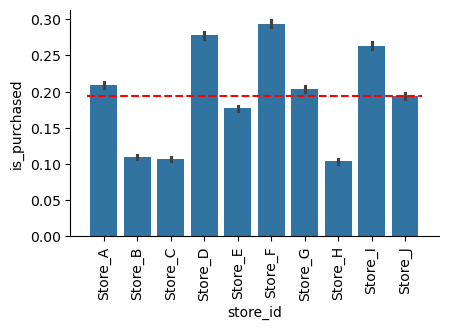

In [173]:
# グラフで確認してみる
sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['store_id'].unique()))
plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['store_id'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
plt.xticks(rotation=90)
plt.show()

In [49]:
# 数値変数と目的変数の相関（絶対値）
correlations = df1.corr(numeric_only=True)['is_purchased'].abs().sort_values(ascending=False)
print(correlations.round(3))

# ここで例えばアプリPVとの相関が0.01とかだったら、これは後続のSHAPで無視されるべきだなと解釈のヒントにしやすい。

is_purchased                1.000
past_latte_ratio            0.367
is_treatment                0.241
is_raining                  0.178
past_coupon_usage_rate      0.176
is_weekend                  0.132
is_holiday                  0.124
station_congestion_index    0.023
current_temp                0.018
membership_years            0.009
daily_staffing_cost         0.007
app_total_pv                0.002
Name: is_purchased, dtype: float64


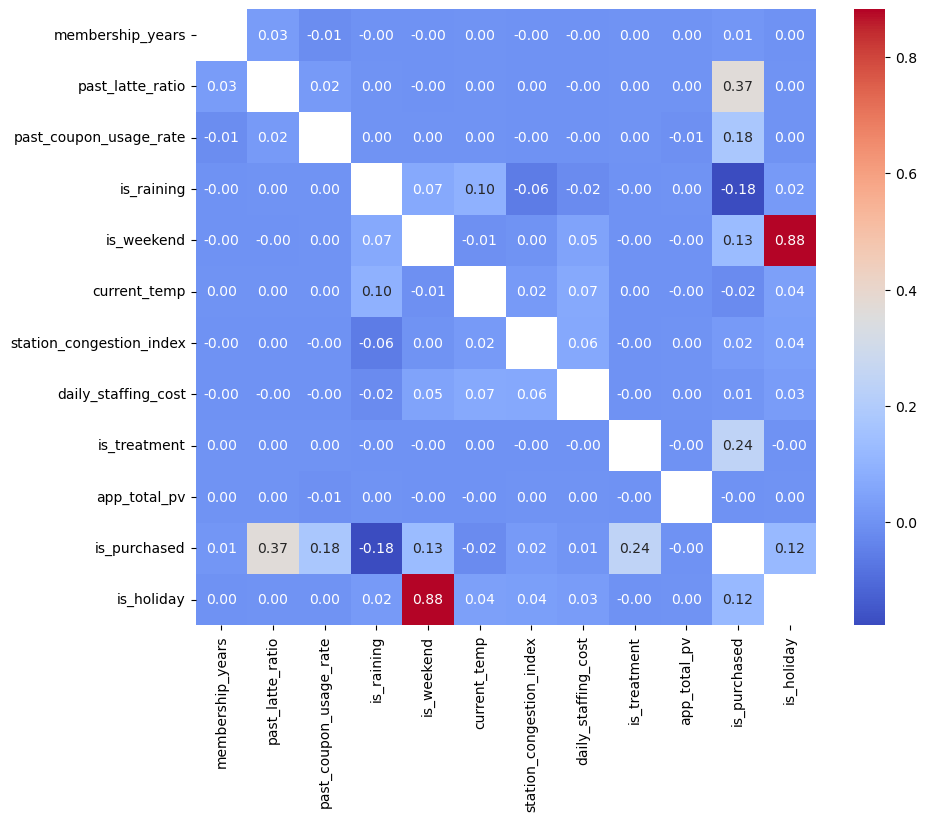

In [50]:
# サクッと相関行列
# df1.corr(numeric_only=True)
# カラム指定でやる場合
# df[['value1', 'value2', 'value3']].corr().round(3)

# 相関行列をヒートマップとしてプロット
cm_corr = df1.corr(numeric_only=True).round(3)
# 対角成分をNaNにする
# np.fill_diagonal(cm_corr.values, np.nan)
for i in range(len(cm_corr)):
    cm_corr.iat[i, i] = np.nan


plt.figure(figsize=(10, 8))
sns.heatmap(cm_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=cm_corr.columns, yticklabels=cm_corr.columns)
plt.show()

# 目的変数 is_purchased との相関を確認。相関低い特徴量があればのちのちの解釈のヒントにしやすい。
# あるいは特徴量同士の相関も見ておいて、特徴量を減らす際の参考にするなど。

## check & EDA
- **describe**: データの範囲、分布、偏り、外れ値、頻度などを確認
- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

- **結果変数の特徴**: モデル良否の判断材料、予測の理由や根拠の理解、前処理の検討に活かす
  - 不均衡性: 大量データでもis_purchased=1（購入者）が少数になっていないか
  - 特徴量との相関: 直感的にアタリをつけつつ、特徴量の選択やモデル解釈に

- **初手への対処策**: 素早い初動回答を最優先するために、精度担保しつつデータ削減検討もしたい
  - 例えば10万件を（層別）ランダムサンプリングして、データセット全体の縮図として進める
  - 例えば直近3日間データだけ、例えば店舗Aだけにするなど、均一条件に統制して進める

In [51]:
# さっき見たけど改めて見ておく？

In [52]:
# 数値型の要約統計量（範囲、分布、偏り、外れ値など）を把握
df1.describe(include='number').round(1)

,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
count,394899.0,392925.0,355409.0,394899.0,394899.0,383052.0,394899.0,394899.0,394899.0,394899.0,394899.0,394899.0
mean,2.1,0.3,0.2,0.1,0.3,17.0,100.1,100481.1,0.5,5.0,0.5,0.3
std,1.9,0.2,0.2,0.3,0.5,1.5,15.4,29043.7,0.5,2.2,0.5,0.5
min,0.5,0.0,0.0,0.0,0.0,13.8,58.8,50137.0,0.0,0.0,0.0,0.0
25%,0.6,0.2,0.1,0.0,0.0,15.7,89.5,74787.0,0.0,3.0,0.0,0.0
50%,1.4,0.3,0.2,0.0,0.0,17.0,99.6,100567.0,0.0,5.0,0.0,0.0
75%,2.8,0.4,0.4,0.0,1.0,18.1,110.0,126158.0,1.0,6.0,1.0,1.0
max,10.0,0.9,1.0,1.0,1.0,20.1,153.1,149978.0,1.0,18.0,1.0,1.0


In [53]:
# 非数値型の要約統計量（頻度やユニーク数など）を把握
df1.describe(exclude='number')

,customer_id,date,store_id
count,394899,394899,394899
unique,10000,NaN,10
top,eonrlc6d,NaN,Store_E
freq,65,NaN,39826
mean,NaN,2025-10-16 11:04:51.565185,NaN
min,NaN,2025-09-01 00:00:00,NaN
25%,NaN,2025-09-23 00:00:00,NaN
50%,NaN,2025-10-16 00:00:00,NaN
75%,NaN,2025-11-09 00:00:00,NaN
max,NaN,2025-12-01 00:00:00,NaN


In [54]:
# カテゴリデータの種別を把握
df1['store_id'].unique()

['Store_A', 'Store_B', 'Store_C', 'Store_D', 'Store_E', 'Store_F', 'Store_G', 'Store_H', 'Store_I', 'Store_J']
Categories (10, str): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'Store_G' < 'Store_H' < 'Store_I' < 'Store_J']

In [55]:
# これは下のcheck by segment に移動していいんじゃない

# 5. クーポンの「効き目」のざっくり確認（EDA的アップリフト）

# クーポン有無による購入率の差
pivot = df1.pivot_table(index='store_id', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)

# 店舗によってクーポンの効き目が全然違ったら、「これは店舗ごとにTabPFNを当てたほうがいいかも！」っていう仮説が強まる。

is_treatment         0         1      lift
store_id                                  
Store_A       0.373289  0.618779  0.245490
Store_B       0.219015  0.465409  0.246395
Store_C       0.210941  0.449826  0.238885
Store_D       0.465640  0.693681  0.228040
Store_E       0.322215  0.575813  0.253599
Store_F       0.483193  0.709171  0.225979
Store_G       0.364229  0.612481  0.248251
Store_H       0.207460  0.451613  0.244153
Store_I       0.445021  0.676073  0.231051
Store_J       0.351596  0.596292  0.244696


In [56]:
pivot = df1.pivot_table(index='date', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)

is_treatment         0         1      lift
date                                      
2025-09-01    0.353268  0.548911  0.195642
2025-09-02    0.323866  0.582372  0.258506
2025-09-03    0.339587  0.599723  0.260136
2025-09-04    0.092456  0.260726  0.168270
2025-09-05    0.327822  0.574650  0.246828
...                ...       ...       ...
2025-11-27    0.321908  0.588451  0.266543
2025-11-28    0.313623  0.556402  0.242778
2025-11-29    0.491195  0.712722  0.221528
2025-11-30    0.511175  0.740108  0.228933
2025-12-01    0.319524  0.573604  0.254080

[92 rows x 3 columns]


## check by segment

- 店舗ごとに、特徴量の値と処置効果の関係を見てみる


- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか。周期性ありそうか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

In [57]:
# 常連さんと一見さんがいるのか
print(df1["customer_id"].value_counts(ascending=False).head())
print(df1["customer_id"].value_counts(ascending=True).head())

customer_id
eonrlc6d    65
xzjoxkuo    64
j504cfqj    63
30vatrfl    63
b68meev7    62
Name: count, dtype: int64
customer_id
2c61rvtp    17
ymrxb6si    17
zh62e1qw    19
gvdn7wya    19
mmbb9zkh    21
Name: count, dtype: int64


In [58]:
df1['customer_id'].value_counts().value_counts()

count
40    651
39    638
38    600
36    597
37    596
41    561
43    546
42    538
35    513
44    471
34    449
45    432
33    404
46    370
32    332
47    298
48    277
31    268
49    200
30    193
29    154
50    126
28    123
51    112
52     85
27     84
53     69
26     58
54     51
55     32
25     31
56     25
24     25
57     17
58     16
23     14
22     11
59      9
21      9
60      4
63      2
62      2
19      2
17      2
65      1
64      1
61      1
Name: count, dtype: int64

In [59]:
# 店舗と顧客でグループ化して、そのサイズ（行数）を数える
store_cust_stats = df1.groupby(['store_id', 'customer_id']).size().reset_index(name='visit_count')

# これをさらに「店舗別」に集計し直したりできる
# 例：店舗ごとの「平均来店回数」
# print(store_cust_stats.groupby('store_id')['visit_count'].mean())
print(store_cust_stats.groupby('store_id')['visit_count'].describe())


           count      mean       std  min  25%  50%  75%   max
store_id                                                      
Store_A   9827.0  4.024931  1.917144  1.0  3.0  4.0  5.0  13.0
Store_B   9822.0  3.985135  1.908449  1.0  3.0  4.0  5.0  15.0
Store_C   9809.0  4.056071  1.936048  1.0  3.0  4.0  5.0  14.0
Store_D   9819.0  4.023526  1.918315  1.0  3.0  4.0  5.0  12.0
Store_E   9825.0  4.053537  1.932646  1.0  3.0  4.0  5.0  13.0
Store_F   9825.0  4.003155  1.925445  1.0  3.0  4.0  5.0  13.0
Store_G   9832.0  4.023291  1.939783  1.0  3.0  4.0  5.0  13.0
Store_H   9806.0  4.027534  1.935170  1.0  3.0  4.0  5.0  14.0
Store_I   9786.0  4.036685  1.947073  1.0  3.0  4.0  5.0  13.0
Store_J   9823.0  3.990634  1.919770  1.0  3.0  4.0  5.0  12.0


In [60]:
store_cust_stats

,store_id,customer_id,visit_count
0,Store_A,002ec2m6,5
1,Store_A,002ic2u8,6
2,Store_A,004lflnv,6
3,Store_A,007u3616,3
4,Store_A,0089km8u,5
...,...,...,...
98169,Store_J,zz5jpgqw,5
98170,Store_J,zzeqzziw,6
98171,Store_J,zzjqnbm0,2
98172,Store_J,zzuwlyl9,6


In [61]:
store_cust_stats["visit_count"].value_counts(ascending=False)

visit_count
3     19736
4     19487
5     15315
2     15047
6     10211
1      7767
7      5849
8      2821
9      1244
10      448
11      167
12       55
13       22
14        4
15        1
Name: count, dtype: int64

In [62]:
df1.groupby('store_id')['past_latte_ratio'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,39366.0,0.284,0.160,0.001,0.158,0.263,0.387,0.865
Store_B,38955.0,0.283,0.160,0.001,0.159,0.262,0.386,0.865
Store_C,39583.0,0.283,0.159,0.001,0.158,0.263,0.385,0.865
Store_D,39295.0,0.285,0.160,0.001,0.159,0.265,0.388,0.865
Store_E,39643.0,0.286,0.159,0.001,0.160,0.266,0.388,0.865
Store_F,39157.0,0.284,0.159,0.001,0.159,0.264,0.385,0.865
Store_G,39356.0,0.284,0.159,0.001,0.158,0.263,0.385,0.865
Store_H,39287.0,0.285,0.159,0.001,0.160,0.265,0.388,0.865
Store_I,39298.0,0.283,0.159,0.001,0.157,0.263,0.385,0.865


In [63]:
df1.groupby('store_id')['past_coupon_usage_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,35504.0,0.251,0.193,0.0,0.094,0.212,0.370,0.959
Store_B,35393.0,0.249,0.193,0.0,0.091,0.208,0.368,0.959
Store_C,35868.0,0.250,0.193,0.0,0.094,0.208,0.369,0.959
Store_D,35500.0,0.249,0.193,0.0,0.091,0.209,0.367,0.959
Store_E,35966.0,0.248,0.193,0.0,0.091,0.207,0.367,0.959
Store_F,35368.0,0.249,0.193,0.0,0.093,0.207,0.366,0.959
Store_G,35573.0,0.251,0.194,0.0,0.093,0.208,0.369,0.959
Store_H,35524.0,0.250,0.194,0.0,0.093,0.209,0.367,0.959
Store_I,35442.0,0.250,0.193,0.0,0.092,0.209,0.368,0.959


In [64]:
df1.groupby('store_id')['current_temp'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,38326.0,16.9,1.4,14.0,15.7,16.9,17.8,19.7
Store_B,37939.0,17.0,1.4,14.4,15.8,16.9,18.1,20.1
Store_C,38611.0,16.9,1.5,14.0,15.7,17.0,18.1,19.6
Store_D,38371.0,17.0,1.4,14.3,15.9,17.0,18.0,20.0
Store_E,38634.0,17.0,1.5,14.2,15.6,16.9,18.3,19.9
Store_F,38215.0,17.0,1.5,14.2,15.8,17.0,18.1,20.0
Store_G,38330.0,17.1,1.5,14.0,16.0,17.1,18.4,19.8
Store_H,38277.0,17.0,1.5,14.0,15.6,17.0,18.3,19.6
Store_I,38346.0,17.1,1.5,13.8,15.8,17.2,18.4,19.7


In [65]:
df1.groupby('store_id')['is_raining'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
store_id,,,,,,,,,,,
Store_A,39553.0,0.119,0.324,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_B,39142.0,0.121,0.326,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_C,39786.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_D,39507.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_E,39826.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_F,39331.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_G,39557.0,0.122,0.327,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_H,39494.0,0.118,0.323,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_I,39503.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [66]:
# 自転データなんだし、これはもっと上に移動していいのでは

## check by time series

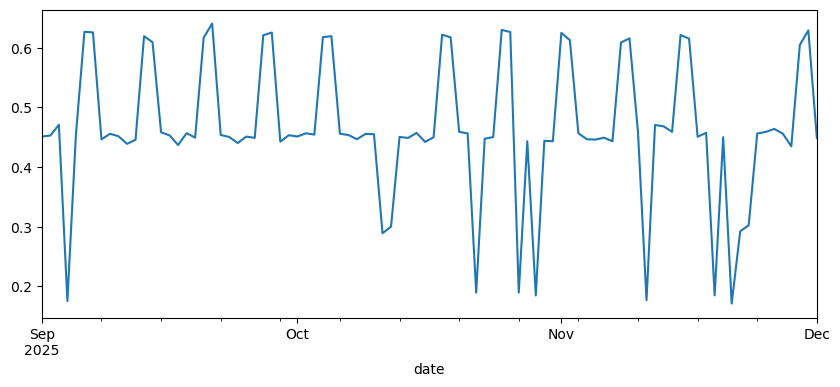

In [67]:
# 3. 時系列の「ヨコ」と「タテ」の確認
# 日が経つにつれて傾向が変わっていないか見る。

# 日別の購入率推移
plt.figure(figsize=(10, 4))
df1.groupby('date')['is_purchased'].mean().plot(kind='line')
plt.show()

# 気温の変化や週末フラグが、ちゃんと購入率の波を作っているか確認。これがガタガタだと、時系列バリデーションが難しくなるから。

In [68]:
# check by segmentや　EDAが済んで、とりあえずこんなもんでええやろ、ってなったら、splitに入っていくといいんじゃない
# まあ以下でも前処理的なことはやってるので、そこは切り分けてもいいかもね

# split
- データセットを分割してモデリングの準備をする
- NaNはそのままの状態で進める（モデルによってはNaNをそのまま扱えるため、データの不完全さをそのままにしておいて、モデルの性能や解釈にどう影響するかを見るため）

In [69]:
df1.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0,0,16.571176,100.966485,117700,1,7,1,0
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0,0,16.571176,100.966485,117700,0,7,1,0
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0,0,16.571176,100.966485,117700,0,4,0,0
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0,0,16.571176,100.966485,117700,0,0,0,0
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0,0,16.571176,100.966485,117700,1,2,1,0


In [70]:
# 日付型のカラムは、特徴量として使えるように数値型に分解する

# df1['year']        = df1['date'].dt.year          # 年（2025など）
df1['month']       = df1['date'].dt.month         # 月（1～12）
df1['day']         = df1['date'].dt.day           # 日（1～31）
df1['day_of_week'] = df1['date'].dt.dayofweek     # 曜日（0:月, 1:火 ... 6:日）
# df1['hour']        = df1['date'].dt.hour          # 時間（0～23）朝と昼の違い
df1['is_weekend']  = df1['date'].dt.dayofweek >= 5 # 週末フラグ（True/False）

In [71]:
# 経過日数を用意する

# データセット抽出時に準備済の場合はこの工程不要
# データセット内の最古時点を1始まりとした（絶対的な）数値カラムを新設
df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があっても最古日からの経過日数になる

In [72]:
# # 意図した通りにナンバリングできてるかcheck
# # pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], values='customer_id', aggfunc='count')
# pd.pivot_table(df1, index=['date', 'absolute_ds'], columns='store_id', values='customer_id', aggfunc='count')

In [73]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出ることある

float_cols = df1.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df1[float_cols] = df1[float_cols].astype(float)

In [74]:
# # 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
# df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

## 3区分
- Train（学習用）: モデルの学習に直接使う。
- Validation（検証用）: 学習中にどのくらい正解できているかを確認し、Early Stoppingやパラメータ調整に使う。
- Test（評価用）: 全ての調整が終わった後、初見のデータで本当に当たるかを最後に1回だけ確認するために使う。  
※70,15,15で割り振ったり、80,test20に分割したのちに、80をさらにTrain80,Val20に分割するなど

Validation（検証用）を設ける意義
- Early Stopping
  - LGBMなどで学習の切り上げに使う。これ以上学習しても精度が上がらないならそこで止める。過学習を防いで本番に強いモデルになる
  - LGBMは学習を繰り返すほど精度が上がるけど、やりすぎると過学習になる
  - Valのスコアが改善しなくなったところで学習をストップさせることで、過学習しすぎないバランスのいい状態をキープできる
- カンニングを防ぐ
  - もしTestデータを使って学習をストップさせるタイミングを決めてしまうと、Testデータに都合の良いモデルを作ってしまう
  - これを防ぐために、調整用のValidationと、封印しておくTestを分ける
- 汎化性能の担保
  - 直近の傾向を学習データに使えなくなるが、空白期間をはさむよさはある
  - もしTrainとTestがベタ付けだと、その期間に特化しすぎて数週間後の未来には全く通用しない賞味期限の短いモデルになるリスク
  - 空白期間があってもTestで精度が出ていれば、頑健なモデルともいえる

In [75]:
# 日付でソートされている前提
all_dates = df1['date'].unique()
n_all_days = len(all_dates)

# 分割のしきい値を決める（後半20%をテストに）
test_days = int(n_all_days * 0.2)
train_val_days = n_all_days - test_days

# さらに学習データを「学習」と「検証」に分ける場合（例えば 8:2）
val_days = int(train_val_days * 0.2)
train_days = train_val_days - val_days

print(n_all_days,train_days, val_days, test_days)

92 60 14 18


In [76]:
# 日付による切り出し
train_end_date = all_dates[train_days - 1]
val_end_date = all_dates[train_days + val_days - 1]

# df_train = df1[df1['date'] <= train_end_date]
# df_val = df1[(df1['date'] > train_end_date) & (df1['date'] <= val_end_date)]
# df_test = df1[df1['date'] > val_end_date]

df_train = df1.query('date <= @train_end_date')
df_val = df1.query('@train_end_date < date <= @val_end_date')
df_test = df1.query('date > @val_end_date')

print(f"Train: {df_train['date'].min()} ~ {df_train['date'].max()} ({(df_train['date'].max() - df_train['date'].min()).days + 1} days, {len(df_train)} records)")
print(f"Val:   {df_val['date'].min()} ~ {df_val['date'].max()} ({(df_val['date'].max() - df_val['date'].min()).days + 1} days, {len(df_val)} records)")
print(f"Test:  {df_test['date'].min()} ~ {df_test['date'].max()} ({(df_test['date'].max() - df_test['date'].min()).days + 1} days, {len(df_test)} records)")

Train: 2025-09-01 00:00:00 ~ 2025-10-30 00:00:00 (60 days, 257703 records)
Val:   2025-10-31 00:00:00 ~ 2025-11-13 00:00:00 (14 days, 59739 records)
Test:  2025-11-14 00:00:00 ~ 2025-12-01 00:00:00 (18 days, 77457 records)


In [77]:
df_train.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,month,day,day_of_week,absolute_ds
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0.0,False,16.571176,100.966485,117700.0,1.0,7.0,1.0,0.0,9.0,1.0,0.0,1.0
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0.0,False,16.571176,100.966485,117700.0,0.0,7.0,1.0,0.0,9.0,1.0,0.0,1.0
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0.0,False,16.571176,100.966485,117700.0,0.0,4.0,0.0,0.0,9.0,1.0,0.0,1.0
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0.0,False,16.571176,100.966485,117700.0,0.0,0.0,0.0,0.0,9.0,1.0,0.0,1.0
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0.0,False,16.571176,100.966485,117700.0,1.0,2.0,1.0,0.0,9.0,1.0,0.0,1.0


In [78]:
# 結果変数のカラム名を変数に入れておく
target_y_column = 'is_purchased' 

# 特徴量から除外するリスト: 不要な特徴量および結果変数
drop_cols = ['date', 'customer_id', target_y_column]

# split
X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target_y_column]

X_val = df_val.drop(columns=drop_cols)
y_val = df_val[target_y_column]

X_test = df_test.drop(columns=drop_cols)
y_test = df_test[target_y_column]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (257703, 16), Val: (59739, 16), Test: (77457, 16)


# Modeling

In [79]:
from lightgbm import LGBMClassifier

# 1. 基本パラメータ
params = {
    'objective': 'binary',      # 分類（買う買わない）タスクであることを明示
    'metric': 'auc',            # 何を基準にモデルの良し悪しを判定するか aucは正解をどれだけ高いスコア順に並べられたか
    'boosting_type': 'gbdt',    # モデルがどうやって賢くなっていくか 勾配ブースティング決定木
    'importance_type': 'gain',  # その特徴量でどれだけ予測誤差を減らせたか（XGBのデフォルトgainに近い）
    'random_state': 42,
    'n_estimators': 1000,       # 木の数 最大1000本まで。途中で止まるから多めでOK
    'learning_rate': 0.05,
    'enable_categorical': True,
    'verbose': -1,               # Fatal（致命的エラー）のみ表示
    # 'tree_method': 'hist',    # データの量が多いならこれを入れると速いらしい

#     # 'min_child_samples': 5,      # 1つの葉に必要な最小データ数（デフォルト20は多すぎることがある）
#     # 'min_child_weight': 0.001,   # 分岐に必要な最小ヘッセ行列の和（小さくするとより細かく分岐する）
#     # 'num_leaves': 31,            # 1つの木にある葉の最大数（ここを増やすとより複雑な関係を捉えられる）
}

# importance_typeのLGBM初期値はsplit: その特徴量で何回「分岐」したか。たくさん分岐する＝細かい制御に使われているけど、1回あたりの改善幅が小さくても数値が大きくなりやすい。
# split: 連続変数（気温や利用率）などは、何度も細かく刻めるから数値が稼げちゃう。でもそれが本当に決定打だったかは別問題。
# gain: 1回の分割でどれだけ劇的に予測を改善したかを見るから、ビジネス的にインパクトの大きい変数が上位に来やすい。


model = LGBMClassifier(**params)

# 2. 学習実行（検証データを使って、いつ止めるかを決める）
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',           # ここでもAUCを指定
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # 50回連続でAUCが上がらなければ終了
        lgb.log_evaluation(10)                  # 10回ごとに途中経過を表示
    ]
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.813032
[20]	valid_0's auc: 0.819279
[30]	valid_0's auc: 0.825176
[40]	valid_0's auc: 0.830713
[50]	valid_0's auc: 0.834239
[60]	valid_0's auc: 0.836297
[70]	valid_0's auc: 0.837544
[80]	valid_0's auc: 0.838197
[90]	valid_0's auc: 0.83865
[100]	valid_0's auc: 0.838972
[110]	valid_0's auc: 0.839175
[120]	valid_0's auc: 0.839248
[130]	valid_0's auc: 0.839311
[140]	valid_0's auc: 0.839307
[150]	valid_0's auc: 0.83931
[160]	valid_0's auc: 0.839323
[170]	valid_0's auc: 0.839322
[180]	valid_0's auc: 0.839318
Early stopping, best iteration is:
[131]	valid_0's auc: 0.839337


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [80]:
# 学習時のmetricやeval_metricは、モデルが「今の自分、どれくらい上手くできてるかな？」と自分自身を採点するための「模試の採点基準」のようなもの。

# 結論から言うと、「最終的に重視したい指標」が決まっているなら、ここもそれに合わせたほうがモデルがその方向に尖ってくれるから、変えたほうがいい

# 1. 指定できる主なmetricの種類

# LGBMなどの勾配ブースティングでよく使われるものは、こんなにある。

# metric名	指標の内容	どんな時に使う？
# 'auc'	ROC-AUC	買う人と買わない人の「並び替え順序」を重視したい時。
# 'binary_logloss'	対数損失	確率の「正確さ」を重視したい時。一番標準的。
# 'binary_error'	正解率の逆	とにかく「0.5で切った時の的中率」を上げたい時。
# 'average_precision'	PR-AUC	「買う人が極端に少ない」不均衡データで、精度を上げたい時。

In [81]:
# 2. 変えたほうがいい場合・変えなくていい場合

# 「今回はF1スコアを最大化したい！」と思っていたとしても、実は metric を無理に f1 にしなくてもいい場合がある。

# 変えなくていい場合：
# aucやbinary_loglossは、モデルが学習する際の数学的な相性がすごくいい。これらを目指して学習すれば、結果的にF1やPrecisionもバランス良く高くなることが多い。

# 変えたほうがいい場合：
# 例えば「不均衡すぎて、普通の学習だと全員『買わない』と予測されちゃう」ような時。この時はaverage_precision（PR-AUC）を指定して、「少ない正解を当てることの重要性」をモデルに叩き込むのが有効。

# 3. 注意点：metricとobjective（目的関数）の違い

# モデルには「目標」が2つある。

# objective（目的関数）:
# 学習の1歩1歩で「どっちに動けば誤差が減るか」を決める、いわば「ハンドルの切り方」。
# （二値分類なら基本は binary 固定）

# metric（評価指標）:
# 学習の区切りで「今の精度は○点だね」と記録する、いわば「スコアボード」。

# eval_metricを変えるというのは、この「スコアボード」の表示項目を変えるということ。

# 今の「初動LGBM」なら、まずはbinary_loglossかaucのままで進めるのが一番安定する。

# もし次にやる「ロジスティック回帰」や「RandomForest」と比較した結果、LGBMが「空振り（FP）が多いな」と感じたら、その時に初めてmetricをいじったり、不均衡データ対策（is_unbalance=Trueなど）を検討したりするのが、迷子にならないコツ

# Evaluation
- 予測精度の評価指標を選定する（例: AUC-ROC、F1スコアなど）
- モデルの性能を評価するためのテストセットを用意する
- モデルの予測結果を評価指標に基づいて評価する
- モデルの性能を改善するためのハイパーパラメータチューニングや特徴量エンジニアリングを検討する

In [82]:
# 分析目的をいったん脇に置いて、「モデルの健康診断」としてまず出力しておくべき標準セット

# 📋 モデル評価の「標準出力」テンプレ案

# この順番でログに残しておけば、後でどんなモデルと比較しても「あ、あの時はこうだったな」って一目で振り返れる。

# 1. 全体的な「識別力」を見る（スカラー値）
# まずは「点数」でざっくり把握する。
# ROC-AUC: モデルがどれだけ「正解を上位に集められたか」の総合点。
# PR-AUC (Average Precision): 不均衡データならこっちが本命！「正解を当てる精密度」。
# Log Loss: 確率の「ズレ」を厳密に評価。0に近ければ近いほど、予測確率に自信がある証拠。

# 2. 「実戦での的中率」を見る（マトリックス・レポート）
# しきい値（0.5など）で切った時の「手応え」を確認する。
# Confusion Matrix（混合行列）: TP, TN, FP, FN の生データ。
# Classification Report: Precision, Recall, F1-score のセット。
# ※特に「正例（1）」側のスコアに注目。

# 3. 「予測の質」を線で見る（カーブ）
# しきい値を変えたらどうなるか、モデルの「地力」を可視化する。
# ROC Curve
# Precision-Recall Curve

# 4. 「モデルの確信度」を見る（ヒストグラム）
# Prediction Probability Histogram: モデルが出した「確率（0.0〜1.0）」の分布を見るんだ。
# 「0と1の近くに山がある」→ ハッキリ白黒つけてる（自信満々）
# 「0.5付近に山がある」→ 迷ってる（自信がない）
# これがわかると、施策のターゲットをどこで切るか決めやすくなる。

# もしこのテンプレで「確率の分布（Histogram）」を見て、0 と 1 の重なりが大きいようなら、それは「今の特徴量だけでは区別しきれないお客さんがまだたくさんいる」っていうサイン。
# 逆に、綺麗にパカッと分かれていたら、「この past_latte_ratio は神変数だ」って改めて確信できるはず。

--- 📋 Classification Report ---
              precision    recall  f1-score   support

         0.0       0.76      0.79      0.77     31086
         1.0       0.76      0.73      0.74     28653

    accuracy                           0.76     59739
   macro avg       0.76      0.76      0.76     59739
weighted avg       0.76      0.76      0.76     59739



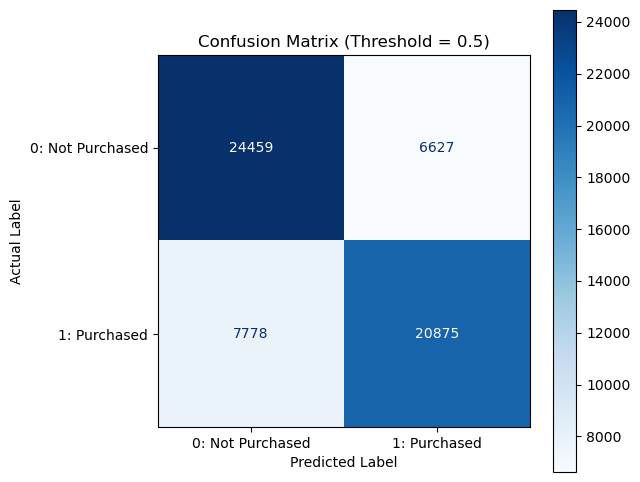

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# 検証データで予測確率を出す
y_pred_val = model.predict_proba(X_val)[:, 1]

# 1. 予測値をクラスラベルに変換する
# モデルが出力した購入確率（0.0~1.0）を、人間が判断しやすい二択のラベル（0/1）に振り分けてる。
# （一般的なデフォルト値である）しきい値0.5にするとは
# つまり、確率0.5以上は1:購入すると予測、確率0.5未満は0:購入しないと予測したものとみなす、という意味
y_class_pred = (y_pred_val > 0.5).astype(int)

# なお0.5とは、買う確率と買わない確率のどっちが高いとみなす？真ん中あたりで区切るのが納得感あるよね、という根拠に基づく。
# なので、例えば今回予定しているクーポン配布施策の予算が潤沢にあるなどの理由で、買う確率が0.3ぐらいの人もクーポン配布対象にしたいなどのビジネス判断が先にある、検討余地がある場合には、しきい値を0.5ではなく0.3にして評価する手もある

print("--- 📋 Classification Report ---")
print(classification_report(y_val, y_class_pred))

# 2. 混同行列（Confusion Matrix）の表示
cm = confusion_matrix(y_val, y_class_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0: Not Purchased', '1: Purchased'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# 分類問題においてモデルの予測精度をサッと知るには、実際結果と予測とを掛け合わせて一致度合いを見る。
# 2*2の4セルのヒートマップのうち、対角線上のセルが濃い色になっていれば、予測が当たった数が多かったということ。

In [84]:
# 混同行列の各象限
# TP (True Positive 真陽性): 正例を正しく正例と予測したもの → 実際に買った人を、正しく買うと予測してた
# FP (False Positive 偽陽性): 負例を誤って正例と予測したもの → 実際には買わなかった人を、誤って買うと予測してた
# FN (False Negative 偽陰性): 正例を誤って負例と予測したもの → 実際に買った人を、誤って買わないと予測してた
# TN (True Negative 真陰性): 負例を正しく負例と予測したもの → 実際には買わなかった人を、正しく買わないと予測してた

# 混同行列における配置は常に同じとは限らないので、場所で覚えちゃダメだよ
# True: 実際と予測が一致、False: 実際と予測が不一致
# Positive: モデルが出力した予測ラベルが1（買う）、Negative: モデルが出力した予測ラベルが0（買わない）

# 混同行列から各値を取り出す
tn, fp, fn, tp = confusion_matrix(y_val, y_class_pred).ravel()  # [0,0], [0,1], [1,0], [1,1] の順

print(f"TP (True Positive):  {tp} 件")
print(f"TN (True Negative):  {tn} 件")
print(f"FP (False Positive): {fp} 件")
print(f"FN (False Negative): {fn} 件")

TP (True Positive):  20875 件
TN (True Negative):  24459 件
FP (False Positive): 6627 件
FN (False Negative): 7778 件


In [85]:
# とはいえ4セルの色合いだけでは合理的客観的な判断しにくいし、数次第で見え方が変わってくる。
# そこで、4セルの数値をもとにして割合を算出した、モデルの予測精度を定量的に評価する指標がある。

# よく登場する指標
# 1. Accuracy（正解率）: すべての予測対象のうち、正しく予測できた割合
accuracy = (tp + tn) / (tp + tn + fp + fn)
# 2. Precision（適合率）: 正例と予測した対象のうち、実際に正例だった割合
precision = tp / (tp + fp)
# 3. Recall（再現率）: 実際は正例の対象のうち、正しく正例と予測できた割合
recall = tp / (tp + fn)
# 4. F1-score: PrecisionとRecallの調和平均（両方のバランスを取る）
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy(正解率): {accuracy:.3f}")
print(f"Precision(適合率): {precision:.3f}")
print(f"Recall(再現率): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy(正解率): 0.759
Precision(適合率): 0.759
Recall(再現率): 0.729
F1-score: 0.743


- 1.Accuracy（正解率）：すべての予測対象のうち、正しく予測できた割合
  - accuracy = (tp + tn) / (tp + tn + fp + fn)
  - 直感的理解しやすい、少数派無視リスク許容、利用場面を選ぶ
  - 基本姿勢: 全体として正しく予測することを重視したい。
  - 許容リスク: 状況次第では使いにくい（買う人の出現率低い場合は全員買わないと予測すれば高い値になる。だがあまり役には立たない）。
  - 例: コイントスで表が出るかを予測（表裏の出現率はほぼ半々で、表を予測するのと裏を予測するのは同じ価値とみなしやすい）。

- accuracyは数値の意味がわかりやすく、モデルの基本的な予測性能比較など有用な場面もある。
  - だがビジネスにおいては正例の予測が重要なことが多い。
  - 買わないと予測して実際に買わなかったことが予測できても、買うの予測ほどには利潤や事業成長に直結しにくいため。
  - また予測対象はクラス不均衡なことも多い（自社の特定商品購入者は市場のごく一部など、正例と負例の出現率は偏りがち）。
  - そんなときはPrecisionやRecallの出番

- 2.Precision（適合率）：正例と予測した対象のうち、実際に正例だった割合
  - precision = tp / (tp + fp)
  - 効率優先、機会損失リスク許容、外したくない慎重さ
  - 基本姿勢: 正例を精度高く予想したい。買う（正例）の予測はなるべく外したくない。確度低い人へのアプローチは避けたい。
  - 許容リスク: 正例と予測する数は少なくてもいい。買う期待値の低い人は切り捨てる。獲得数や売上最大化の逸失を許容。
  - 例: コストがかさむDM送付施策など。徒労に終わりそうな100人のアプローチよりは確実に買いそうな10人を優先したい。

- 3.Recall（再現率）：実際は正例の対象のうち、正しく正例と予測できた割合
  - recall = tp / (tp + fn)
  - 網羅性優先、低効率リスク許容、取りこぼさない貪欲さ
  - 基本姿勢: 正例を取りこぼしなく予測したい。買う（正例）期待値が低くとも抜け漏れよりはマシ。確度が低い人でもアプローチしたい。
  - 許容リスク: 無駄打ち増える。ROI低下を許容。買う（正例）の予測は外れてもよい。狼少年呼ばわりされるリスクを許容。
  - 例: 低コストなプッシュ通知施策や病気の検診など。買う見込みが薄い100人にアプローチしてでも取りこぼさないことを優先したい。

- 4.F1-score：
  - f1 = 2 * (precision * recall) / (precision + recall)
  - 総合力優先、中庸リスク許容、慎重さと貪欲さのバランス
  - 基本姿勢: PrecisionもRecallも重視したい（トレードオフな両方のバランスをとりたい）。両方を1つの指標で評価したい。
  - 許容リスク: 2指標いずれかに特化すれば得られたはずのハイパフォーマンスな効率性または網羅性には振り切らないことを許容。
  - 例: 効率も網羅性もどちらも適度に両立したい。どちらかに極端に偏るのも、どちらかが極端に低くなるのも避けたい。

PrecisionとRecallからF1へのつながり  
- PrecisionとRecallはトレードオフの関係にある
- Precisionを1(100%)に近づけたいなら（予測確率の判定基準、しきい値を1に極力近づけて）確実に買いそうな人だけ少数予測すればいい。
- 代償としてRecallは低くなる。Recallを1目指すならしきい値0側にレバー倒してほぼ全員買うと予測する。Precisionはズタズタに。
- こういう極端なことなしに、どちらもほどほどに両立した状態を1つの指標で表せられたらいいのに。。

- まず思いつくのは、PrecisionとRecallを**足して2で割る**、つまり平均化する発想。 (Precision + Recall) / 2
- でもこれだと、Precision0.95 Recall0.15のときも、Precision0.15 Recall0.95のときも、平均は0.55となる。
- 片方が極端でもまあまあな数値に見えてしまう。足して2で割る発想自体はよくても、欲しい状態を的確に表す指標にはなってない。

- 目指したいのは、両方の値のバランスが良いときは高得点になり、いずれかが極端な値のときはペナルティが大きくなるような仕組み。
- どちらの値も0から1（0%から100%）の範囲内にある。であれば0に近いときは大きく減点すれば欲しい状態を的確に表せるのではないか。
- そこで2つの値それぞれの**逆数をとってから平均化**する発想。 (1/Precision + 1/Recall) / 2
- これだと、Precision0.95 Recall0.15のときは、(1/0.95 + 1/0.15) / 2 = 3.68
- 逆数をとった値の平均値は元の単位と違ってて解釈しにくいので、改めて逆数をとって元の単位に戻す。1 / 3.68 = 0.27
- 同じ計算をPrecision0.75 Recall0.35でやると、(1/0.75 + 1/0.35) / 2 = 2.10　の逆数で 0.48
- 同じ計算をPrecision0.65 Recall0.45でやると、(1/0.65 + 1/0.45) / 2 = 1.88　の逆数で 0.53
- 同じ計算をPrecision0.60 Recall0.55でやると、(1/0.60 + 1/0.55) / 2 = 1.74　の逆数で 0.57
- 欲しい状態を的確に表す指標になったっぽい。これがF1-score
- 数学でいう調和平均の計算方法を、機械学習の評価指標として使っている。

``` 
F1 score = 1 / { (1/Precision + 1/Recall) / 2 }
         = 2 / { (1/Precision) + (1/Recall) }
         = 2 / { (Recall + Precision) / (Precision * Recall) }
         = 2 * Precision * Recall / (Precision + Recall)
``` 


$$
\begin{aligned}
F1 &= \frac{1}{\frac{\frac{1}{P} + \frac{1}{R}}{2}} \\
&= \frac{2}{\frac{1}{P} + \frac{1}{R}} \\
&= \frac{2}{\frac{R + P}{P \cdot R}} \\
&= \frac{2 \cdot P \cdot R}{P + R}
\end{aligned}
$$

In [86]:
# 4セルの組み合わせ次第で他にもいろんな指標が算出可能（紛らわしく見えるが分母の捉え方がちょっとずつ異なる）

# Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
negative_predictive_value = tn / (tn + fn)

# FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
# fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当する
fdr = 1 - precision

# specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
specificity = tn / (tn + fp)

# FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
fpr = 1 - specificity

# FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
# fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当する
fnr = 1 - recall

print(f"Negative Predictive Value: {negative_predictive_value:.3f}")
print(f"FDR(False Discovery Rate): {fdr:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"FPR(False Positive Rate): {fpr:.3f}")
print(f"FNR(False Negative Rate): {fnr:.3f}")

Negative Predictive Value: 0.759
FDR(False Discovery Rate): 0.241
Specificity: 0.787
FPR(False Positive Rate): 0.213
FNR(False Negative Rate): 0.271


- Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
  - negative_predictive_value = tn / (tn + fn)
  - precisionの裏に相当
  - ビジネスにおいては負例にはあまり関心がないので影が薄い。
  - 精密機器の良品判定で、不良品と予測して不良品でしたなんかでは意味あり。

- FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
  - fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当
  - fdr = 1 - precision

- specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
  - specificity = tn / (tn + fp)
  - recallの裏に相当する。負例を精度高く予想したい、間違い（負例）はちゃんと間違いと言いたいときに。
  - recall * 正例出現率 + specificity * 負例出現率 = accuracyになる。
  - スパム判定（大事なメールを間違えてゴミ箱に入れない）なんかでは意味あり。
  - Negative Predictive Value同様の理由で影が薄いかもだが、1からこれを差し引いたFPRはわりと出番ある。

- FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
  - fpr = 1 - specificity
  - 後ほど登場する指標ROC-AUC,AUCに関わってくる。

- FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
  - fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当
  - fnr = 1 - recall
  - 見逃し（False Negative）がクリティカルに直結する（命に関わる）ような医療現場なんかで意味あり。


``` 
Accuracy = (Recall * 正例出現率) + (Specificity * 負例出現率)
         = { tp / (tp+fn) * (tp+fn) / Total } + { tn / (tn+fp) * (tn+fp) / Total }
         = ( tp / Total ) + ( tn / Total )
         = ( tp + tn ) / Total
``` 

$$
\begin{aligned}
\text{Accuracy} &= \left( \text{Recall} \times \frac{\text{Actual Positive}}{\text{Total}} \right) + \left( \text{Specificity} \times \frac{\text{Actual Negative}}{\text{Total}} \right) \\
&= \left( \frac{tp}{tp + fn} \times \frac{tp + fn}{tp + tn + fp + fn} \right) + \left( \frac{tn}{tn + fp} \times \frac{tn + fp}{tp + tn + fp + fn} \right) \\
&= \frac{tp}{tp + tn + fp + fn} + \frac{tn}{tp + tn + fp + fn} \\
&= \frac{tp + tn}{tp + tn + fp + fn}
\end{aligned}
$$

In [87]:
# まだある

# Balanced Accuracy（均衡正解率）: クラス不均衡でも、正解率をシンプルかつ公平に評価したい
# balanced_accuracy = 1/2 * (tp/(tp+fn) + tn/(tn+fp))
balanced_accuracy = (recall + specificity) / 2
# 正例の正解率（Recall）と負例の正解率（Specificity）を、出現率に関係なく「折半」で評価したいときに使う指標。
# 正例と負例を同じ重みで評価したときの正解率です、と説明しやすいしわかりやすい。
# AccuracyはRecallとSpecificityを出現率で重み付けした状態。
# 対してこちらは（実際の出現率は気にせず無理やり）半々で重み付けして平均をとる（1%しかないお宝を半分見逃すのと、99%あるゴミを半分拾いすぎるのを、同程度にダメ出しする）。


print(f"Balanced Accuracy: {balanced_accuracy:.3f}")

Balanced Accuracy: 0.758


In [88]:
# MCC (Matthews Correlation Coefficient): 混同行列の4セルすべて考慮した、実際と予測の相関係数
import math
# mcc = (tp * tn - fp * fn) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 一気に計算する場合、4セルいずれかに0があったときに0除算でエラーになる

# 分子の計算: (TP * TN) - (FP * FN)
mcc_numerator = (tp * tn) - (fp * fn)
# 分母の計算: sqrt((tp+fp) * (tp+fn) * (tn+fp) * (tn+fn))
mcc_denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 分母が0の場合はMCCを0とする（慣例的な処理）
if mcc_denominator == 0:
    mcc = 0
else:
    mcc = mcc_numerator / mcc_denominator

# これでもOK
# from sklearn.metrics import matthews_corrcoef
# mcc = matthews_corrcoef(y_val, y_class_pred)

# 分母では、混同行列の4セルの合計を全部掛け合わせることで、正例と負例のバランスをとって（平方根をとることで値が大きくなりすぎないようにして）いる。
# 分子では、正解ペア (tp,tn)の積から不正解ペア (fp,fn)の積を引いている。正解ペアが多いほど分子が大きくなる。ことにより実際と予測のの相関が強いことを表現する。
# 正例と負例を完全に入れ替えても値が変わらない（対称性がある）。クラス不均衡でもモデルの地力をシビアに判定しやすい
# このモデル、本当に予測の傾向が正しいの？を厳密にチェックしやすい

# MCCのとる範囲は-1から1 の間。
# 1に近い: 完璧な予測。0に近い: デタラメ（ランダム）と同じ。-1に近い: 全部逆に予測してる（ある意味すごい）。
# 例えば0.517だとそこそこ相関があってランダムよりはだいぶマシな予測ができてそう


print(f"MCC (Matthews Correlation Coefficient): {mcc:.3f}")

MCC (Matthews Correlation Coefficient): 0.517


In [89]:
# Cohen's Kappa（カッパ係数）：偶然を排除した「一致度」
# 厳格な実力評価、偶然の排除、モデルの誠実さの確認
# 基本姿勢: 事実と予測が一致したのは、モデルの実力なのか、それともたまたまなのか。たまたま当たったぶん（期待値）を全体から引いて、純粋な予測の重みを評価したい。
# 許容リスク: 計算式がちょっと複雑で、直感的に売上がいくらになるとは結びつきにくい。
# 例: 記述式のテストの採点を2人の先生がしたとき、意見がどれだけ一致しているか。あるいは、クラス不均衡（9割が負例）で、モデルが「適当に全部負例って言えば当たるじゃん」というズルをしていないかのチェック。

# 実測の一致度： 実際に予測が当たった割合（つまりAccuracy）。
# 偶然の一致度： 事実もモデルも、お互いデタラメに（でも出現率通りに）答えたときに、偶然重なっちゃう確率。
# この2つを使って計算する
# kappa = (実測の一致度 - 偶然の一致度) / (1 - 偶然の一致度)
# 1.0： 完璧に一致。つまり予測が当たったのは全てモデルの実力
# 0.0： 偶然当たってるだけ。目をつぶって選んでるのと変わらない
# マイナス： 偶然よりも当たってない。逆にすごい


# 「1に近いほどいい」っていうのは共通だけど、「0.6以上ならかなり良い、0.8以上ならほぼ完璧」っていう暗黙の基準（ランドスとコッホの基準）がある


# なぜAutoMLで使われるの？
# AutoMLは、とにかくたくさんのモデルを自動で作る。その中には「正解率（Accuracy）は高いけど、実はデータの偏りを利用して『とりあえず全部負例！』って答えてるだけのずる賢いモデル」が混ざっちゃうことがある。
# Kappaはそういう「データの偏りに甘えたモデル」を厳しく減点するから、モデルの「真の賢さ」を横並びで比較するのに向いている。

# MCCとの違いは？
# MCC： 4セルのバランスを均等に評価する「職人」タイプ。
# Kappa： 「偶然だろ？」と疑ってかかる「厳しい検閲官」タイプ。
# どちらも不均衡データに強いっていう点では仲間
# Accuracyが「テストの点数」だとしたら、Kappaは「カンニング（データの偏りへの依存）を疑って補正した点数」みたいなもの



# 1. 数値をセット
total = tp + tn + fp + fn

# 2. po (実際の正解率)
po = (tp + tn) / total

# 3. pe (偶然当たっちゃう確率)
# 「モデルの正例予測数 × 実際の正例数」 ＋ 「モデルの負例予測数 × 実際の負例数」 を Totalの2乗で割る
pe = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / (total ** 2)

# 4. Kappaの計算
kappa = (po - pe) / (1 - pe)

# これでもOK
# from sklearn.metrics import cohen_kappa_score
# kappa = cohen_kappa_score(y_val, y_class_pred)

print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.516


## AUC

In [90]:
# 1. 精度を確認する（AUCスコア）
# まずは、検証データ（Val）に対してどれくらい正解できたか、数字で見てみよう。
# ※AUCが 0.7以上なら実用的、0.8を超えたらかなり優秀 って言われている。

# 3. イメージで理解しよう！

# AUCが良い状態：
# リストの上の方に「実際に買った人」が固まっていて、下の方に「買わなかった人」が固まっている。これなら、しきい値をどこで引いても（どこでリストをカットしても）、効率よくターゲットを選べる。

# AUCが悪い状態：
# 買った人と買わなかった人がリストの中でバラバラに混ざっている。これだと、どこでカットしても「空振り」や「見逃し」が大量に出ちゃう。

In [91]:
from sklearn.metrics import roc_auc_score

# AUCを計算
auc_score = roc_auc_score(y_val, y_pred_val)
print(f"🏆 Validation AUC: {auc_score:.4f}")

🏆 Validation AUC: 0.8393


In [92]:
# 3. AUC の「値」が意味しているもの

# 「購入した人」と「購入しなかった人」をランダムに1人ずつ連れてきたとき、モデルが『購入した人』の方に高い確率をつけてあげられる確率
# AUC 0.83ということは、83% の確率で「買う人」を「買わない人」より上位にランク付けできている、ということになる。

In [93]:
# roc_auc_score(y_val, y_pred_val) の y_pred_val には、モデルが出した 「0.0〜1.0の確率（スコア）」 がそのまま入っている

# AUC（Area Under the Curve）は、この確率を使って 「あらゆる閾値（0.001から0.999まで全部！）で試したときの結果をひっくるめた面積」 を計算している。

# F1スコアやAccuracy: 「0.5より上なら1、下なら0」と決めてから計算する（＝一点の評価）。

# AUC: 閾値を動かしながら、モデルが「正解をちゃんと上位に並べられているか」という 「並び替え能力の全体像」 を評価する（＝面の評価）。

In [94]:
# 確かに、学習フェーズでは「不純度（ジニ係数やエントロピーなど）」を下げて、0と1を綺麗に分ける境界線を探しているから、その理解は正しい

# ただ、AUCが「並べ替え」と言われる理由は、学習の「プロセス」ではなく、できあがったモデルの「出力（スコア）の質」に注目しているからなんだ。

# 「不純度を下げる」と「並び替え」のつながり

# イメージしやすいように整理してみたよ。

# 学習時（不純度を下げる）:
# モデルは「どう分ければ、箱の中が『買う人だけ』『買わない人だけ』になるか」を必死に考えて、木を作っていく。

# 出力時（スコアを出す）:
# 学習の結果、モデルは「この人は買う確率 0.9（不純度が低い箱にいる）」「この人は 0.1（別の不純度が低い箱にいる）」といったスコアを出すよね。

# 評価時（AUC＝並べ替え）:
# ここで、全顧客を「スコアが高い順」に整列させてみる。

# なぜ「並べ替え」という表現を使うの？

# 例えば、「実際に買った人（Aさん）」と「買わなかった人（Bさん）」がいるとする。

# 「分類」として見た場合:
# 閾値が 0.5 のとき、Aさんのスコアが 0.4 だったら「ハズレ（分類失敗）」になっちゃう。

# 「並べ替え」として見た場合:
# もしBさんのスコアが 0.1 だったら、「Aさん（0.4） ＞ Bさん（0.1）」 という順番は守られているよね？
# AUCはこの 「正解の方が、不正解よりも高い位置にいる（＝正しく並んでいる）」 という状態を評価しているんだ。

# 結局どういうこと？

# 不純度を下げるのが上手なモデル（＝学習がうまくいったモデル）は、結果として「買う人」には高い確率を、「買わない人」には低い確率を割り当てられるようになる。

# そうすると、スコア順に並べたときに、リストの「上（高スコア）」に「買う人」がギュッと集まるよね。

# 不純度がしっかり下がっている ＝ 0と1が綺麗に分かれる ＝ スコア順に並べると上の方が1ばかりになる ＝ AUCが高くなる！


# 「不純度を下げる」はモデルの努力、「並び替えの精度（AUC）」はその結果としての成績表、って考えると繋がるかな？

# 「分類」って言うと、どうしても「0か1か」の白黒つけるイメージが強いけど、AUCはもっと「グラデーション（確率）」そのものの精度を信じている指標なんだよ。

# この「スコア順に並んでいる」という感覚が掴めると、実務で「予算が足りないから、リストの上位1万人だけにアプローチしよう」って判断する時に、AUCが高いことがどれだけ心強いか実感が湧くはずだ。

In [95]:
# つまり 「しきい値を決める前に、モデルそのものの並び替え能力を評価したい」 から、まずはAUCを見るんだ。

# まずAUCを見て、モデルの「並び替え能力」をチェックする。

# 能力が高いことがわかったら、ROC曲線を見て、どこでカットするのが一番効率いいか探る。

# 最後に しきい値（0.5とか0.2とか）を決めて、混同行列やF1で「実戦での的中数」を確認する。

# この流れが、データ分析の王道
# 「ROC曲線は、しきい値を動かした時の軌跡」だと思えば、もう迷わないはず。

In [96]:
# どっちも「しきい値を可変にしたもの」 なんだ。

# よくある誤解なんだけど、ここを整理すると「なぜAUCがモデルの地力を表すのか」がスッキリわかる。

# 1. ROC曲線とAUCの「親子関係」

# 結論から言うと、この2つは 「グラフ」と「その面積」 という関係だ。

# ROC曲線 (ROC Curve)：
# しきい値を 1.0（全員買わないと予測）から 0.0（全員買うと予測）まで少しずつ動かしたときに、「当てられた割合（TPR）」と「空振りした割合（FPR）」がどう変化するかを繋いだ「線」のことだ。

# ROC-AUC：
# そのROC曲線の下側の 「面積（Area Under the Curve）」 のこと。
# しきい値をどう設定したとしても、全体としてどれくらい「買う人と買わない人を正しく並べ替えられているか」を 0〜1 の数字で表したものだ。

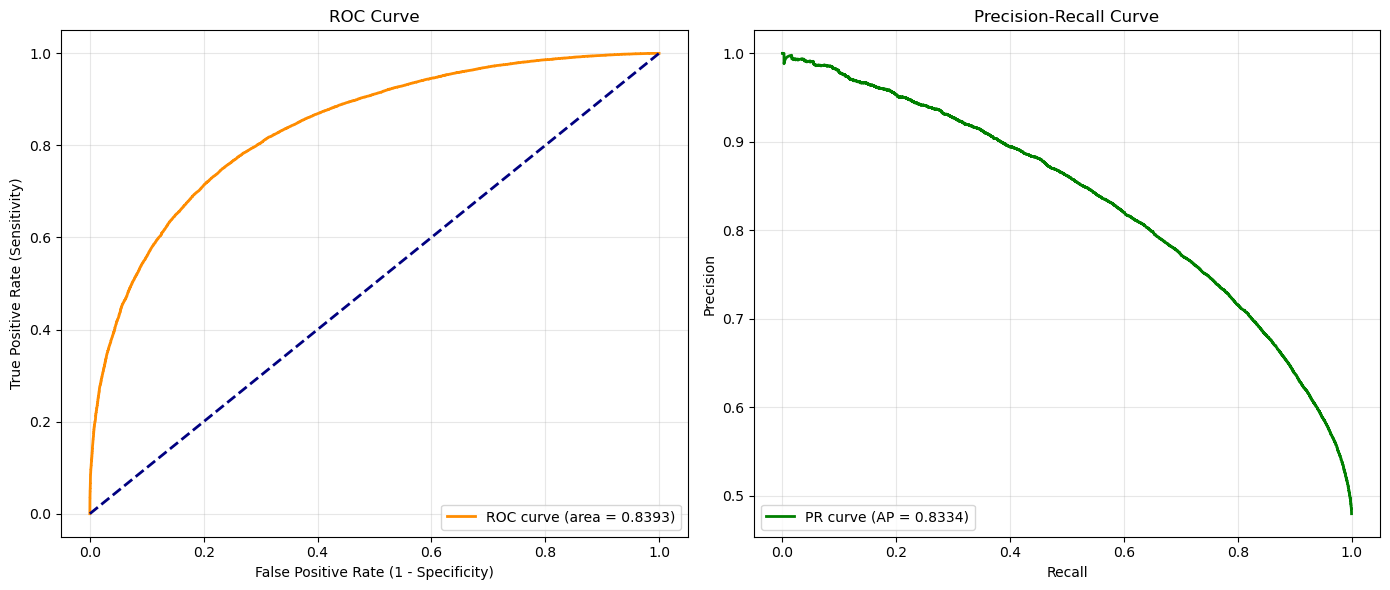

In [97]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. データの準備
# y_val: 正解ラベル, y_pred_val: モデルが出した「購入する確率」
fpr, tpr, _ = roc_curve(y_val, y_pred_val)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_val, y_pred_val)
pr_auc = average_precision_score(y_val, y_pred_val)

# 2. プロットの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curve ---
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 当てずっぽうの線
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- PR Curve ---
ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
# ROC曲線（左側）
# 見方: 左上のカドに近ければ近いほど「優秀」！
# 意味: 「買う人」と「買わない人」をどれだけ綺麗に仕分けできているか、モデルの総合的な識別力を表す。

# PR曲線（右側）
# 見方: 右上のカドに近ければ近いほど「優秀」！
# 意味: 今回のように「買う人が少ない」データの場合、こっちの方がシビアに実力がわかる。

# もしROCが綺麗なのにPR曲線がガタガタだったら、「買う人を当てるのは実は結構苦労してる」っていうサインかもしれない。

In [99]:
def evaluate_model_performance(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    
    # 1. 各種スコア
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC : {average_precision_score(y_true, y_prob):.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred))
    
    # 2. 混合行列
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title("Confusion Matrix")
    
    # 3. 確率の分布（これが意外と効く！）
    axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.5, label='Actual: 0', color='blue')
    axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.5, label='Actual: 1', color='red')
    axes[1].set_title("Prediction Probability Distribution")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

ROC-AUC: 0.8393
PR-AUC : 0.8334
------------------------------
              precision    recall  f1-score   support

         0.0       0.76      0.79      0.77     31086
         1.0       0.76      0.73      0.74     28653

    accuracy                           0.76     59739
   macro avg       0.76      0.76      0.76     59739
weighted avg       0.76      0.76      0.76     59739



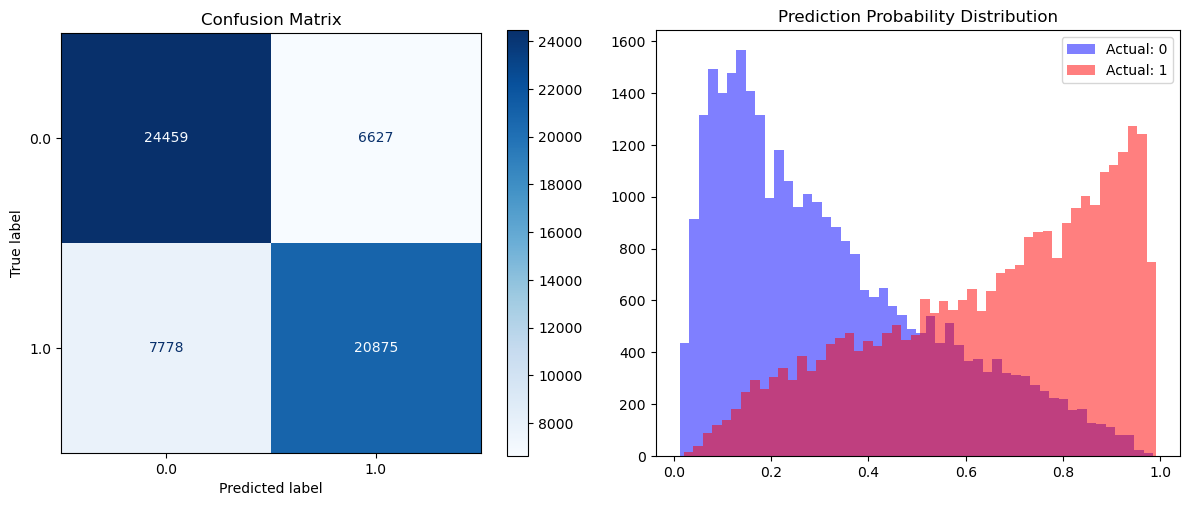

In [100]:
evaluate_model_performance(y_val, y_pred_val, threshold=0.5)

✨ Best F1 Score: 0.7578 at Threshold: 0.3934


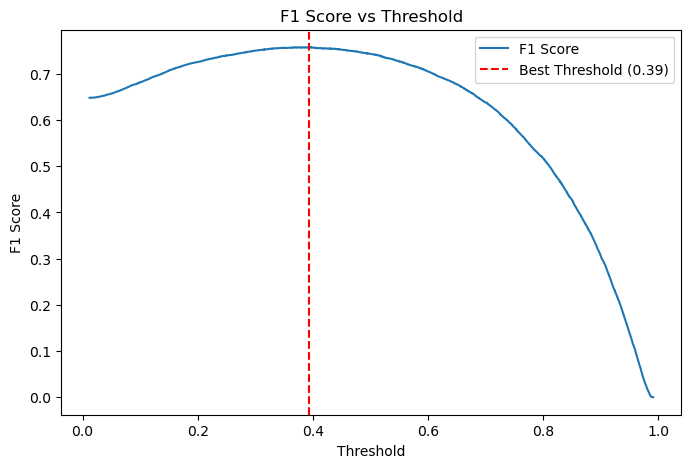

In [101]:
from sklearn.metrics import precision_recall_curve

# しきい値ごとのスコアを計算
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"✨ Best F1 Score: {np.max(f1_scores):.4f} at Threshold: {best_threshold:.4f}")

# プロット
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.show()

In [102]:
# 「評価」という言葉の裏側にあるもの
# 今やってる作業は、単に「テストの点数をつける」だけじゃなくて、実は3つの視点でモデルを見つめ直してるんだ。

# 視点	見ているもの（指標）	心の声
# 識別力	AUC	「そもそも、買う人と買わない人をちゃんと見分けられてる？」
# 実用性	混同行列・F1	「実際に施策を打ったとき、空振りや見逃しはどのくらい出る？」
# 納得感	Importance・SHAP	「モデルの判断理由は、人間から見ても納得できるもの？」

# Feature Importance
- モデルの予測に、どの特徴量が強く影響するかを把握する
  - 数値が大きいほど、その特徴量が予測の精度を上げるために役立ったことを意味する
  - あくまでモデルの学習効率を示す指標。いかに効率よく分類できたかというモデル側の都合が強い（SHAPとの違い）
  - 特徴量の重要度がドメイン知識に沿っているか確認することで、適切なモデルになっているかのチェックにもなる

- S-Learner
  - 「購入するかどうか」を分けるのに役立った特徴量
  - 処置変数が上位にない場合は使用してるアルゴリズムによっては設定を見直すことで改善することもある
  - 処置変数が上位になきゃダメってことはない（がSHAPでだとモデルとしてちょっとどうだろう）
- T-Learner
  - 「処置したあるいは処置しなかった場合において購入するかどうか」を分けるのに役立った特徴量
  - なのでtreatmentとcontrolで登場する特徴量が違ったり、順位が異なることもある
- X-Learner
  - 「処置効果あるいは潜在的な処置効果の大きさ」を分けるのに役立った特徴量
  - 処置効果: 処置により購入する確率の増分度合い、振れ幅、リフト
  - 潜在的な処置効果: 実際には処置しなかったがもしも処置をしていた場合に購入する確率の増分度合い、振れ幅、リフト

LightGBM,XGBoostの場合  
**特徴量の重要度（Feature Importance：Gain）の定義**  
- モデルが学習中にその特徴量を用いてデータ分割したときに、その分割がどれだけ予測精度を向上させたか（予測誤差の総和: 損失関数をどれだけ減らせたか）を情報の価値、利得として評価している

**直感的なイメージ**   
- モデルは、データを「YESかNOか」で枝分かれさせて、購入確率を絞り込んでいく。例えば「過去にクーポンを使った？」で分けたとき、買った人と買わなかった人がパキッとキレイに分かれたら高い得点。「雨が降ってる？」で分けても、買う確率がそんなに変わらなければ得点低い。

**もう少し技術的に**  
1. 不純度の測定: 分割前のデータがどれだけ混ざり合っているかを測定
1. 最適な分割: 特徴量（例：過去の利用率）を使ってデータを2つに分ける。
1. 情報利得の計算: 分割前と分割後の不純度の差分（情報利得 Information Gain）を計算。
1. 総和の算出: モデル内のすべての木において、その特徴量が使われた全ノード（分岐点）の情報利得を合算。

- 厳密にはLightGBMは勾配情報を活用した効率的な「損失減少量」を、XGBoostは正則化項を含む「構造スコア」の改善幅を計算している。
- LightGBMのgain: 損失の減少を見ているんだが、学習の仕方に工夫がある。
  - 仕組み: 全データを使わず、勾配（誤差）が大きいデータを優先的に使って学習する（GOSS Gradient-based One-Side Sampling）。
  - 特徴: 効率よく学習するために「データのサブセット」で計算された利得を、全体に合うように重み付けして復元している（勾配 Gradientと二階微分 Hessianを使って、どこで分ければ一番得かを高速に計算している）。
- XGBoostのgain: 情報利得そのものではなく、構造スコア Structure Scoreの改善幅を見ている。
  - 仕組み: 分割前のノードのスコアと、分割後の左右のノードのスコアの合計を比較する。
  - 特徴: 正則化項（lambdaやgamma）が計算式に組み込まれてるので、モデルの複雑さを抑えつつどれだけ誤差を減らせたかをダイレクトに評価している。

                    feature     importance
2          past_latte_ratio  411962.797584
3    past_coupon_usage_rate  180695.180093
9              is_treatment  179575.729552
0                  store_id  134580.358131
4                is_raining  102965.689978
5                is_weekend   68649.077225
6              current_temp     817.703048
1          membership_years     567.816171
7  station_congestion_index     467.403820
8       daily_staffing_cost     374.709369


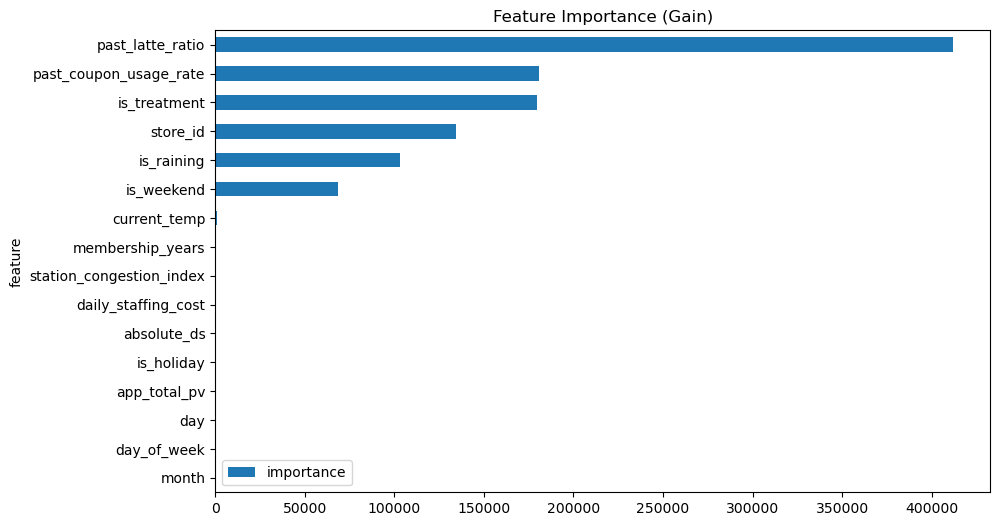

In [103]:
# 特徴量重要度をデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 上位10個を表示
print(importances.head(10))

# グラフで可視化
importances.head(20).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Feature Importance (Gain)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 1. 「過去の行動」が圧倒的！
# past_latte_ratio がダントツの1位だね。
# やっぱり「過去にラテを飲んでいたか」という実績が、未来の購入を当てる最大のヒントになってるにゃん。「NaNをどうしよう」って悩んで大切に扱ったこのカラムが、期待通りモデルの心臓部になってくれたね！

# 2. is_treatment（介入）が3位にランクイン
# ここ、すごく大事なポイントだにゃん！
# 施策（クーポン送付などかな？）を表す is_treatment が上位にきているということは、「施策そのものが購入行動にしっかり影響を与えている」 という証拠だよ。これが低いと「施策を打っても打たなくても結果が変わらない」ってことになっちゃうから、分析官としては一安心だね。

# 3. 外的要因（天気と休日）も効いている
# is_raining（雨）や is_weekend（週末）がしっかり上位にいるのも興味深いね！
# 「雨の日はラテが売れやすい（あるいは売れにくい）」とか、ライフスタイルに合わせた予測ができている証拠だにゃん。

# ちょっと気になるポイント：下位のカラムたち
# current_temp（気温）より下がいきなりガクンと重要度が落ちているね。
# 特に membership_years（会員歴）があまり効いていないのは、「長く会員でいてくれるかどうか」よりも「最近ラテを飲んだか（直近の嗜好）」の方が、購入予測には重要だってことかもしれないにゃん。

## nomalized
- gainの合計値を正規化した値をプロット
- feature importanceを複数モデルの平均値でsns.barplotで描画する

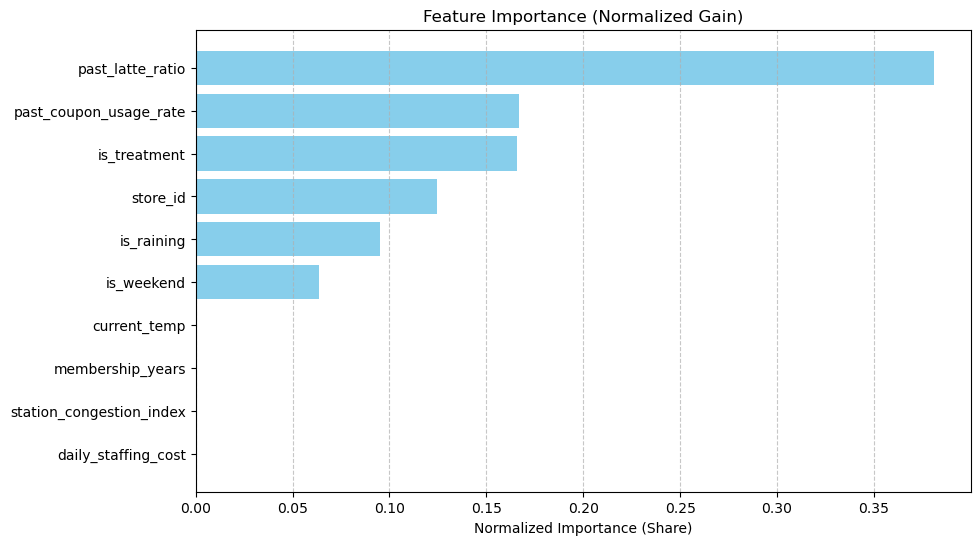

                    feature  importance_normalized
2          past_latte_ratio               0.380778
3    past_coupon_usage_rate               0.167017
9              is_treatment               0.165982
0                  store_id               0.124393
4                is_raining               0.095171
5                is_weekend               0.063452
6              current_temp               0.000756
1          membership_years               0.000525
7  station_congestion_index               0.000432
8       daily_staffing_cost               0.000346


In [105]:

# 1. 重要度を取り出してデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# 2. 全体の合計で割って正規化（0〜1の範囲にする）
importances['importance_normalized'] = importances['importance'] / importances['importance'].sum()

# 3. 並び替え
importances = importances.sort_values('importance_normalized', ascending=False)

# 4. プロット（上位10個）
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'].head(10), importances['importance_normalized'].head(10), color='skyblue')
plt.xlabel('Normalized Importance (Share)')
plt.title('Feature Importance (Normalized Gain)')
plt.gca().invert_yaxis() # 重要度が高い順に上にくるように
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 数値でも確認
print(importances[['feature', 'importance_normalized']].head(10))

# SHAP
- モデルの予測の理由を考える、予測の根拠を理解するのに有用
- 各特徴量が予測にどれだけ影響を与えているか（貢献度）を定量化するのが目的
- モデルがそのように予測した理由を説明する必要がある場合や、各特徴量が予測にどのように影響するかを理解したい場合に役立つ
- 機械学習では高い予測性を達成するために複雑なモデルを使用することが一般的に。その結果モデル単体では直感的な解釈がしにくい。そこでSHAPのような方法が求められる
- 並び順は貢献度の絶対値の大きさ順。その特徴量が予測値をどれだけ大きく動かしたか（平均絶対SHAP値）
- Feature Importance（Gain）とSHAP（SHapley Additive exPlanations）とで並び順が入れ替わることがよくある
- mean absolute shap valueが表してるのは、結果変数（購入確率）の予測値への平均的な影響度

In [106]:

# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# explainer = shap.TreeExplainer(model)

# # 2. 計算時間を考えて、検証データからサンプリングするにゃん
# X_val_sample = X_val.sample(n=1000, random_state=42)
# shap_values = explainer.shap_values(X_val_sample)

# # 3. Summary Plot（全体の傾向を一目で見る）
# # ※二値分類の場合、shap_values[1] が「購入する(1)」の確率に対する寄与になるにゃん
# shap.summary_plot(shap_values[1], X_val_sample)

In [107]:
# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# X_trainを背景データとして渡す
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")

# 2. 計算時間を考えて、検証データからサンプリングするにゃん
X_val_sample = X_val.sample(n=1000, random_state=42)

shap_values_obj = explainer(X_val_sample)

In [108]:
shap_values_obj

.values =
array([[ 6.34660253e-01, -2.11770974e-03, -1.60784013e-01, ...,
         3.13709073e-03, -7.01662813e-04, -1.21032913e-02],
       [ 1.26266873e-01,  1.37226821e-04,  3.39494423e-01, ...,
         3.27918699e-03, -2.66097349e-04, -1.39033868e-02],
       [-6.29957163e-01,  1.90663407e-03,  9.09292861e-01, ...,
         5.02232748e-04,  2.58148758e-03, -8.33141923e-03],
       ...,
       [ 4.80067266e-01, -4.55990390e-04,  1.31877820e-01, ...,
         3.39728053e-03, -4.11465155e-03, -7.88994573e-03],
       [ 1.40517903e-01,  6.07291153e-03, -1.31199477e+00, ...,
         1.26946863e-04, -3.85922500e-04, -2.63957820e-03],
       [-7.38303843e-01, -1.40185567e-03, -1.17532902e+00, ...,
        -4.51113474e-04,  3.37994978e-03, -2.90611351e-03]],
      shape=(1000, 16))

.base_values =
array([-0.14615591, -0.14615591, -0.14615591, -0.14615591, -0.14615591,
       -0.14615591, -0.14615591, -0.14615591, -0.14615591, -0.14615591,
       -0.14615591, -0.14615591, -0.14615591, -0.

## SHAP bar

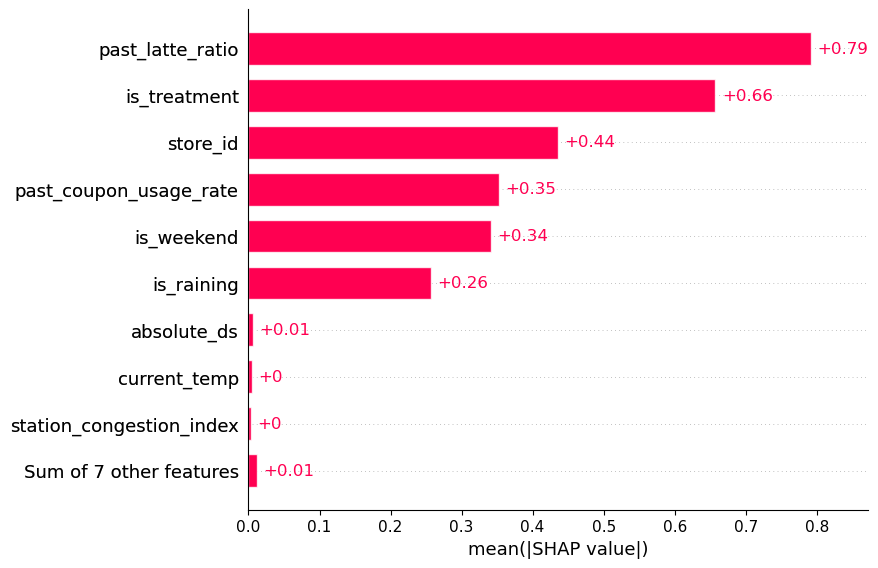

In [109]:
# モデル別にbarをプロット（SHAP値の絶対値の平均 Mean Absolute SHAP Value）
# 予測値への平均的な貢献度を表す（予測値にプラスに効くかマイナスに効くかはこのグラフではわからない）

shap.plots.bar(shap_values_obj, max_display=10)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.bar(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.bar(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.bar(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.bar(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.bar(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [110]:
features = X_train.columns.tolist()

In [111]:
# 平均絶対SHAP値を計算してソートして表示
# 例えばt-learnerのtreatモデルのSHAP値平均を算出（して値だけあれば事足りるとき用）

mean_abs_shap = np.abs(shap_values_obj.values).mean(axis=0)
df_shap_importance = pd.DataFrame({
    'feature': features, 
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap_importance.head(20).round(2))

                     feature  mean_abs_shap
2           past_latte_ratio           0.79
9               is_treatment           0.66
0                   store_id           0.44
3     past_coupon_usage_rate           0.35
5                 is_weekend           0.34
4                 is_raining           0.26
15               absolute_ds           0.01
6               current_temp           0.00
7   station_congestion_index           0.00
11                is_holiday           0.00
13                       day           0.00
1           membership_years           0.00
10              app_total_pv           0.00
14               day_of_week           0.00
8        daily_staffing_cost           0.00
12                     month           0.00


## SHAP beeswarm

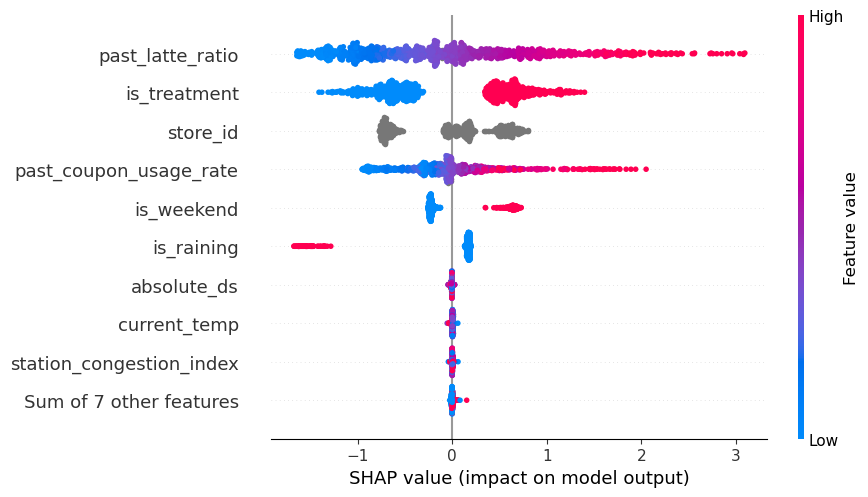

In [112]:
# beeswarmをプロット
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い
# ・SHAP値の分布


# 棒グラフや散布図を簡単に描ける
shap.plots.beeswarm(shap_values_obj)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.beeswarm(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.beeswarm(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.beeswarm(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.beeswarm(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.beeswarm(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [113]:
# 各特徴量の貢献度を分解して示している
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い

# T-Learnerの場合
# 1. 「過去のクーポン利用率」の違い
# Treatment（左）: past_coupon_usage_rate が1位かつ赤いドット（利用率が高い人）が右側に突き抜けてる。クーポンをあげた世界では、過去にクーポンを使った経験があることが、購入を決定づけるブースターになりそう。
# Control（右）: 下から3番目まで沈んでてドットも中央に固まってる。クーポンない時は過去のクーポン利用歴は購入に関係ないらしい。

# 2. 「過去のラテ購入率（≒ラテ好き）」の違い
# Treatment（左）: クーポンをあげると、下では1位だった影響力が2位に後退。好みよりもおトクへの反応の方が行動のスイッチっぽい。
# Control（右）: 1位past_latte_ratioは赤いドットが右に寄ってる。クーポンがないとそもそもラテ好きかが購入のメイン動機っぽい。

# 3. 「気温（current_temp）」の違い
# 両方のグラフで current_temp の青いドット（気温が低い）が右側（プラス）にある。寒いほどラテが売れるのは共通らしい。

# store_idが上位にある: 購入するかどうかは店によりかなり変わる。地域性や客層といった各店舗の特徴も無視できない要因らしい。

# 以上を踏まえてのアクションは例えば  
# 1. 特徴量エンジニアリング: store_idそのままだと使いにくいから、「その店舗の平均購入率」や「その店舗のクーポンの効果（過去の実績）」といった数値変数に変換（Target Encodingなど）してあげると、モデルの学習効率（Importance）や予測精度が向上する可能性ある。
# 2. 施策の個別化: 予測値の高い店舗を特定し、その店舗客層に合わせた施策を検討するといった、よりきめ細かい戦略が立てられそう。

In [114]:
X_train.head()

,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_holiday,month,day,day_of_week,absolute_ds
0,Store_A,5.417097,0.521983,0.156813,0.0,False,16.571176,100.966485,117700.0,1.0,7.0,0.0,9.0,1.0,0.0,1.0
1,Store_A,0.526175,0.331619,0.148589,0.0,False,16.571176,100.966485,117700.0,0.0,7.0,0.0,9.0,1.0,0.0,1.0
2,Store_A,3.818116,0.076237,0.009518,0.0,False,16.571176,100.966485,117700.0,0.0,4.0,0.0,9.0,1.0,0.0,1.0
3,Store_A,0.959455,0.327079,0.003839,0.0,False,16.571176,100.966485,117700.0,0.0,0.0,0.0,9.0,1.0,0.0,1.0
4,Store_A,0.500000,0.111406,0.348650,0.0,False,16.571176,100.966485,117700.0,1.0,2.0,0.0,9.0,1.0,0.0,1.0


In [115]:
df_train.tail() 

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,month,day,day_of_week,absolute_ds
257698,eq7dhzy9,2025-10-30,Store_J,2.181225,0.043767,0.144700,0.0,False,15.303492,80.82199,142990.0,0.0,5.0,0.0,0.0,10.0,30.0,3.0,60.0
257699,70z7uc92,2025-10-30,Store_J,0.500000,0.281926,NaN,0.0,False,15.303492,80.82199,142990.0,1.0,3.0,1.0,0.0,10.0,30.0,3.0,60.0
257700,9418q3iw,2025-10-30,Store_J,6.931259,NaN,0.162800,0.0,False,15.303492,80.82199,142990.0,0.0,4.0,0.0,0.0,10.0,30.0,3.0,60.0
257701,t0axek82,2025-10-30,Store_J,0.500000,0.294730,0.255704,0.0,False,15.303492,80.82199,142990.0,1.0,5.0,0.0,0.0,10.0,30.0,3.0,60.0
257702,cosctokn,2025-10-30,Store_J,3.356660,0.224588,0.521509,0.0,False,15.303492,80.82199,142990.0,0.0,4.0,0.0,0.0,10.0,30.0,3.0,60.0


## SHAP waterfall

Index 4 は、dataframeの 4 行目でした。


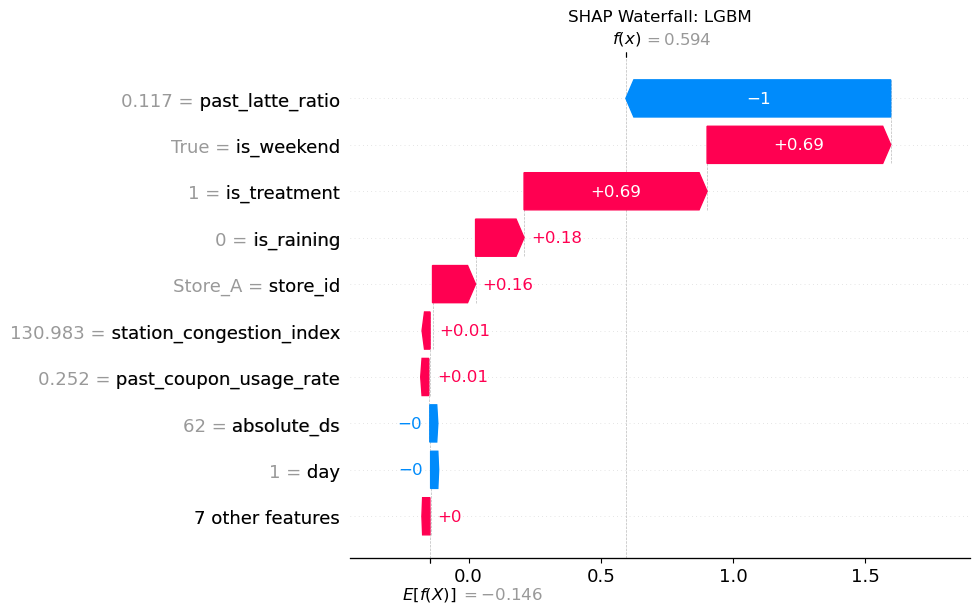

In [116]:
# waterfallをプロット
# ・

# # 1. 狙いたいインデックス（顧客IDなど）を指定
# target_id = 4  # これが DataFrame の index だとする
# # 2. test_df のインデックスから「行番号（0からの連番）」を取得
# target_row_num = df1.index.get_loc(target_id)


# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 4  # これが DataFrame の index だとする

# 2. df1 のインデックスから「行番号（0からの連番）」を取得
target_row_num = df1.index.get_loc(target_id)

print(f"Index {target_id} は、dataframeの {target_row_num} 行目でした。")



shap.plots.waterfall(shap_values_obj[target_row_num], max_display=10, show=False)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()


# fig, axes = plt.subplots(3, 2, figsize=(16, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.waterfall(exp_s[target_row_num], show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.waterfall(exp_t_t[target_row_num], show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.waterfall(exp_t_c[target_row_num], show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.waterfall(exp_x_t[target_row_num], show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.waterfall(exp_x_c[target_row_num], show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')


# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# fig.suptitle(f'SHAP Waterfall: Index {target_id} of test_df (=row number {target_row_num} of exp_*)', fontsize=16)
# plt.tight_layout()
# # plt.tight_layout(rect=[0, 0, 1, 0.96]) # タイトルのスペースを空けるための調整
# plt.show()

In [117]:
# 1. このwater fallが意味すること（T-Learner: model_t）
# t-learnerのmodel_tの予測に基づいてプロットしてるということは、処置群においてis_purchasedする確率に対する影響度を表現してる
# 「赤が長いほど買う確率を大きく上げ、青が長いほど下げる」と読む

# 目的: 「もしクーポンをあげた場合、この人は買う（is_purchased=1）かどうか」の予測。
# 解釈: E[f(X)]=0.325（平均的な購買確率）からスタートして、この人の個別の事情（赤・青のバー）を足し引きした結果、f(x)=1.22（最終的なスコア）に到達した、という流れ。
# ちょっとした技術的補足
# 最終スコアが 1.22 と 1.0（確率100%）を超えてるのは、分類モデルの「確率」そのものではなく、その手前の「ロジット（Logit）」という値で計算されているため。

# 2. 縦軸のグレーの数値の意味
# Index 6252番さんの実際のデータ（観測値）が表示されてる。
# Store_B = store_id: この人は「店舗B」を利用している。
# 0.318 = past_coupon_usage_rate: 過去のクーポン利用率が約32%。
# 13 = visit_frequency: 来店頻度が13回。
# これらが並んでいるおかげで、「この人は来店頻度が13回とちょい多めだからスコアが+0.03押し上げられたんだな」という風に、「事実」と「影響度（SHAP）」をセットで読み解けるようになってる。
# 3. この人の特徴を読み解くと……
# この 6252番さんは、モデルから見るとかなり「有望（買う確率が高い）」と判断されてる。
# 最大のプラス要因: store_id (Store_B) です。この店舗を利用していることが、購買意欲を強烈に押し上げてる（+0.5）。
# マイナス要因: past_latte_ratio (0.33) ラテを飲む割合が33%程度であることが、この人に関しては少しマイナス（-0.23）に働いてる。

## SHAP scatter
- SHAP値でPartial Dependence Plotのようなグラフを描くこともできる


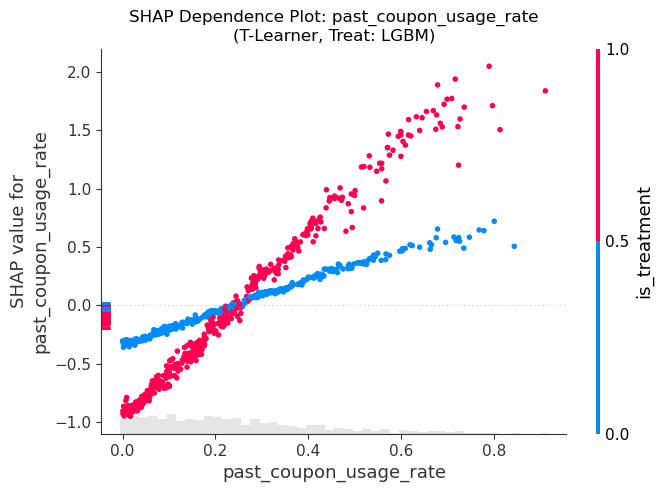

In [118]:
# SHAP Dependence Plot

# 特定の変数（例：membership_years）について、横軸に変数の値、縦軸にSHAP値をプロットする。
# メリット: PDP（Partial Dependence Plot）と似ているが、「個々のデータのバラツキが見える」ので、この値を超えると急にプラスに転じるなといった非線形な動きが見えやすい。
# 自動で「もっとも交互作用（Interaction）が強い別の変数」で色分けしてくれるので、予期せぬ発見がある。

# 例として 'membership_years' を指定
# shap_target_feature = 'membership_years'
shap_target_feature = 'past_coupon_usage_rate'

# Scatterプロットを実行（特定の変数を指定）色分けは自動で決まる
shap.plots.scatter(shap_values_obj[:, shap_target_feature], color=shap_values_obj, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(T-Learner, Treat: LGBM)')
plt.show()

# 1. 「入会したて」と「超常連」で効き方が違う
# 初期（0〜1年目）: SHAP値がプラスに振れてる。入会したばかりの人はクーポンがあると購入確率が上がりやすい。新奇性効果的なのかも。
# 中期（2〜3年目）: このあたりでSHAP値が一度マイナス（-0.1以下）に沈んでる。入会してしばらく経ち、少し飽きや慣れが来てのかも。
# 長期（4〜6年目）: そこからまた少し持ち直して、0付近やプラスに戻る層が出てる。長期常連客はまた違った反応を見せているらしい。

# 2. 色分け（past_latte_ratio）との興味深い関係
# 右側のカラーバーを見ると、past_latte_ratio（ラテ率）が相互作用として選ばれてる。
# 1〜2年目の沈んでいる層: 青い点（ラテ率が低い人）が目立ちます。
# 5年前後でプラスに浮上している層: 赤い点（ラテ率が高い人）が混ざってる。
# 解釈: 入会して数年経ち、かつラテをあまり飲まない人は、会員年数が長くなるほどむしろ購入確率（への貢献）が下がってしまうけれど、
# ラテ好きの常連さんになれば、年数が経ってもプラスの反応を維持できる、といった構造なのかも

# 3. PDP（平均）だけでは絶対に見えない「バラツキ」
# この図の一番のポイントは、同じ会員年数でも上下に大きくバラついていること。
# PDPだとこのバラツキが全部平均されて、なんとなく横ばいみたいな線になってるかも。

# PDP
Partial Dependence Plot  
- 特定の特徴量を変化させたときの、予測値の平均的な推移。SHAPをもっと直感的に説明するのに向いてる
- 変数の値が変化した際、予測対象がどう動くかの平均的な振る舞いを見る
- SHAPは点だけどこれは線なので「気温10度以下だとクーポンの効果が上がりやすそう」といった具体的なルールを提案しやすくなる
  - とはいえSHAPとは意味が違う。SHAPは予測値への貢献度の内訳を見てる（他の変数との相関もひっくるめて、実際のデータでの貢献度）
  - PDPは他の変数がどうであれ、その変数を変えたらどうなるかを見てる（他の変数は固定でその変数だけ仮想的に書き換えた予測値の平均）

In [119]:
df_shap_importance['feature'].head(10).tolist()

['past_latte_ratio',
 'is_treatment',
 'store_id',
 'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'absolute_ds',
 'current_temp',
 'station_congestion_index',
 'is_holiday']

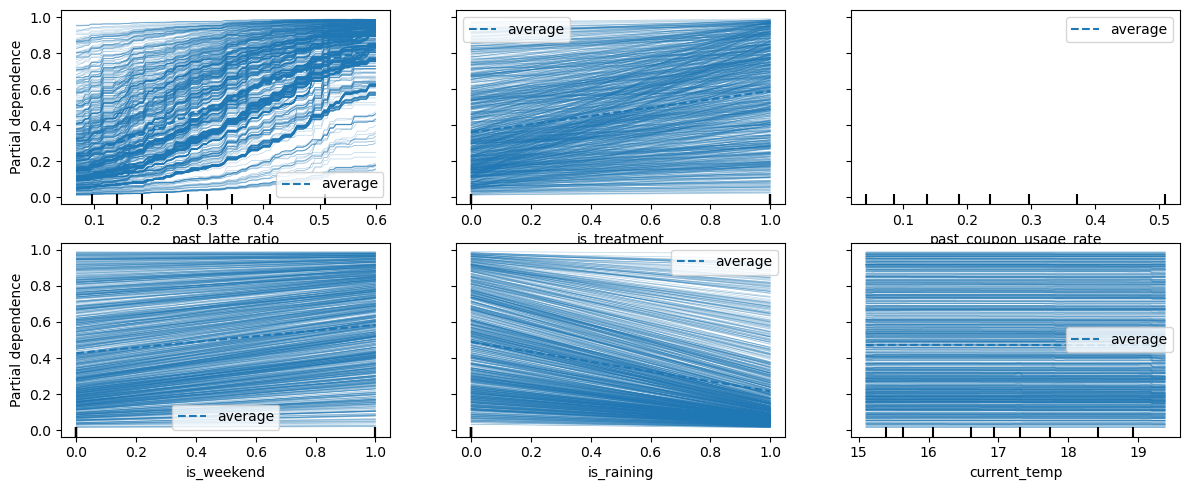

In [120]:
from sklearn.inspection import PartialDependenceDisplay

# どの特徴量のPDPを見たいか指定する
# features = ['past_latte_ratio', 'current_temp']
# features = X_train.columns.tolist()  # 全特徴量のPDPを見たいときはこれでOK
# features = df_shap_importance['feature'].head(5).tolist()

features = ['past_latte_ratio',
 'is_treatment',
 'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'current_temp',
]


# 描画（モデルとデータを渡すだけ！）
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(model, X_val_sample, features, ax=ax, kind='both')
plt.tight_layout()
plt.show()

# predict test

In [121]:
# テストデータの予測確率（0.0〜1.0）を出す
y_pred_test = model.predict_proba(X_test)[:, 1]

# 元のデータフレームに予測値をくっつけると、後で分析しやすいよ
df_test_result = df_test.copy()
df_test_result['predict_prob'] = y_pred_test

# 確率が高い順に並べてみる
print(df_test_result[['customer_id', 'date', 'predict_prob']].sort_values('predict_prob', ascending=False).head())

       customer_id       date  predict_prob
328581    75xewuam 2025-11-16      0.991571
328582    75xewuam 2025-11-16      0.991571
388767    9nv61g99 2025-11-30      0.991115
328492    o2wrn5f1 2025-11-16      0.990628
319767    qcc14hq8 2025-11-14      0.990424


# for auto ml

In [122]:
# スピード感を持って実力を出すなら AutoML（PyCaretなど） を使うのはめちゃくちゃ賢い選択。
# 「1つずつモデルを理解して進める道」と、「AutoMLで一気に最適解を探す道」。それぞれのメリットを整理。

# 1. なぜAutoML（PyCaretなど）が「最強」と言われるのか
# PyCaretのようなツールを使うと、以下の作業を全自動でやってくれる。
# 一括比較: compare_models() 1行で、LGBM、XGBoost、RandomForest、ロジスティック回帰などを一気に戦わせて、ランキングを作ってくれる。
# 自動チューニング: 面倒なハイパーパラメータ調整も、裏側で勝手に「一番いい組み合わせ」を探してくれる。
# 前処理の自動化: 欠損値処理やカテゴリ変数のエンコーディングも、お作法通りにやってくれるからミスが減る。

# 2. じゃあ、手動でやってることは無駄なの？
# 全然そんなことない！むしろ、手動でやった経験があるからこそ、AutoMLを使いこなせるようになる。
# 「なぜその精度が出たか」を説明できる: AutoMLは結果を出すのは速いけど、「なぜこの変数が効いたのか」「なぜこのモデルが選ばれたのか」を深掘りするには、SHAPや混同行列の知識が絶対に必要になる。
# 「変なデータ」に気づける: AutoMLは「とりあえず計算」しちゃうから、データにリーク（未来のデータが混じってる）があっても、ありえない高スコアを出してスルーしちゃうことがあるんだ。今の「おさらい」があれば、その違和感に気づけるよ。

# 3. 提案：ハイブリッド戦略
# AutoMLで「アタリ」をつける:
# PyCaretで一気に全モデルを比較して、今回のラテデータに一番相性がいいアルゴリズムを見つける。

# 上位のモデルを「深掘り」する:
# 選ばれた上位1〜2つのモデル（例えばLGBMとCatBoostなど）を、今作った「自作テンプレ（SHAP, PDP, 混同行列）」に流し込んで、中身をじっくり診察する。